# Laboratorio 4 — Análisis de Datos GeoEspaciales
## Cianobacteria en los lagos de Atitlán y Amatitlán con Sentinel-2

Universidad del Valle de Guatemala — CC3084 Data Science — Semestre II 2026

In [1]:
#!pip install openeo rasterio numpy pandas matplotlib folium geopandas shapely

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio
import openeo
import folium

# Las divisiones de los índices generan 0/0 en píxeles sin dato; se manejan como NaN.
np.seterr(divide="ignore", invalid="ignore")

DATOS = Path("data")
(DATOS / "raw").mkdir(parents=True, exist_ok=True)
(DATOS / "resultados").mkdir(parents=True, exist_ok=True)


---
## 1. Conexión al API de Sentinel-2

Usamos el módulo `openeo` contra el backend del *Copernicus Data Space Ecosystem*.
`authenticate_oidc()` hay que abrir el navegador para iniciar sesión con nuestro usuario de Copernicus Browser y el token queda guardado para las siguientes ejecuciones.

In [3]:
connection = openeo.connect("https://openeo.dataspace.copernicus.eu").authenticate_oidc()
connection

Authenticated using refresh token.


<Connection to 'https://openeo.dataspace.copernicus.eu/openeo/1.2/' with OidcBearerAuth>

---
## 2. Áreas de interés y fechas

11 fechas por lago, elegidas por su baja nubosidad. 

In [4]:
lago_atitlan = {
    "west": -91.326256,
    "east": -91.07151,
    "south": 14.5948,
    "north": 14.750979,
}
lago_amatitlan = {
    "west": -90.638065,
    "east": -90.512924,
    "south": 14.412347,
    "north": 14.493799,
}

LAGOS = {"Atitlan": lago_atitlan, "Amatitlan": lago_amatitlan}

In [5]:
# Fechas oficiales del laboratorio con su nubosidad reportada.
ESCENAS = pd.DataFrame(
    [
        ("Atitlan",   "2025-01-18",  0.02, "Sentinel-2B"),
        ("Atitlan",   "2025-04-13",  0.54, "Sentinel-2C"),
        ("Atitlan",   "2025-05-13",  4.37, "Sentinel-2C"),
        ("Atitlan",   "2025-07-17",  3.57, "Sentinel-2A"),
        ("Atitlan",   "2025-11-21",  3.15, "Sentinel-2A"),
        ("Atitlan",   "2025-12-29",  3.17, "Sentinel-2C"),
        ("Atitlan",   "2026-02-12",  0.04, "Sentinel-2B"),
        ("Atitlan",   "2026-03-24",  3.17, "Sentinel-2B"),
        ("Atitlan",   "2026-04-13",  0.01, "Sentinel-2B"),
        ("Atitlan",   "2026-04-28",  4.96, "Sentinel-2C"),
        ("Atitlan",   "2026-07-22",  4.02, "Sentinel-2B"),
        ("Amatitlan", "2025-01-28",  0.06, "Sentinel-2B"),
        ("Amatitlan", "2025-04-15",  0.09, "Sentinel-2A"),
        ("Amatitlan", "2025-04-28",  1.03, "Sentinel-2B"),
        ("Amatitlan", "2025-11-24",  0.50, "Sentinel-2B"),
        ("Amatitlan", "2026-01-08",  0.77, "Sentinel-2C"),
        ("Amatitlan", "2026-02-02",  0.39, "Sentinel-2B"),
        ("Amatitlan", "2026-02-07",  0.02, "Sentinel-2C"),  # cobertura parcial (~57%)
        ("Amatitlan", "2026-03-29",  0.01, "Sentinel-2C"),
        ("Amatitlan", "2026-04-13",  0.09, "Sentinel-2B"),
        ("Amatitlan", "2026-04-28",  4.96, "Sentinel-2C"),
        ("Amatitlan", "2026-06-19", 13.00, "Sentinel-2A"),
    ],
    columns=["lago", "fecha", "nubosidad", "satelite"],
)

ESCENAS

,lago,fecha,nubosidad,satelite
0,Atitlan,2025-01-18,0.02,Sentinel-2B
1,Atitlan,2025-04-13,0.54,Sentinel-2C
2,Atitlan,2025-05-13,4.37,Sentinel-2C
3,Atitlan,2025-07-17,3.57,Sentinel-2A
4,Atitlan,2025-11-21,3.15,Sentinel-2A
5,Atitlan,2025-12-29,3.17,Sentinel-2C
6,Atitlan,2026-02-12,0.04,Sentinel-2B
7,Atitlan,2026-03-24,3.17,Sentinel-2B
8,Atitlan,2026-04-13,0.01,Sentinel-2B
9,Atitlan,2026-04-28,4.96,Sentinel-2C


---
### 2.1 Descarga de los datos raster

Solo descargamos las 9 bandas que necesitan los tres índices, remuestreadas a
**20 m** (la resolución nativa de B05, B07, B8A, B11 y B12). Así evitamos bajar
escenas completas.

| Índice | Bandas |
|---|---|
| NDVI | B04, B08 |
| NDWI | B03, B08 |
| Cianobacteria (NDCI + máscara de agua) | B02, B03, B04, B05, B07, B08, B8A, B11, B12 |

Usamos el producto **L2A** (reflectancia de superficie, ya corregida
atmosféricamente), que es el mismo que usa el cuaderno de ejemplo del curso.

In [6]:
BANDAS = ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12"]


def descargar_escena(lago, fecha):
    """Descarga las bandas de un lago en una fecha. Si el archivo ya existe, no repite la descarga."""
    ruta = DATOS / "raw" / f"{lago}_{fecha}.tif"
    if ruta.exists():
        return ruta

    # openEO pide un intervalo; usamos [fecha, fecha+1] para traer solo ese día.
    dia_siguiente = (pd.Timestamp(fecha) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")

    cubo = connection.load_collection(
        "SENTINEL2_L2A",
        spatial_extent=LAGOS[lago],
        temporal_extent=[fecha, dia_siguiente],
        bands=BANDAS,
    ).resample_spatial(resolution=20, projection=32615)  # UTM 15N, 20 m

    job = cubo.create_job(out_format="GTIFF", title=f"{lago}_{fecha}")
    job.start_and_wait()
    job.get_results().download_file(ruta)
    return ruta

In [7]:
# Descarga de las 22 escenas. Puede tardar; si se interrumpe, basta con volver a
# correr la celda: las escenas ya descargadas se saltan.
for fila in ESCENAS.itertuples():
    try:
        descargar_escena(fila.lago, fila.fecha)
        print("OK    ", fila.lago, fila.fecha)
    except Exception as error:
        print("FALLO ", fila.lago, fila.fecha, "->", error)

OK     Atitlan 2025-01-18
OK     Atitlan 2025-04-13
OK     Atitlan 2025-05-13
OK     Atitlan 2025-07-17
OK     Atitlan 2025-11-21
OK     Atitlan 2025-12-29
OK     Atitlan 2026-02-12
OK     Atitlan 2026-03-24
OK     Atitlan 2026-04-13
OK     Atitlan 2026-04-28
OK     Atitlan 2026-07-22
OK     Amatitlan 2025-01-28
OK     Amatitlan 2025-04-15
OK     Amatitlan 2025-04-28
OK     Amatitlan 2025-11-24
OK     Amatitlan 2026-01-08
OK     Amatitlan 2026-02-02
OK     Amatitlan 2026-02-07
OK     Amatitlan 2026-03-29
OK     Amatitlan 2026-04-13
OK     Amatitlan 2026-04-28
OK     Amatitlan 2026-06-19


---
## 3. Cálculo de los índices

Replicamos en Python el script **Cyanobacteria Chlorophyll-a NDCI**
(CyanoLakes, Kravitz & Matthews) de <https://custom-scripts.sentinel-hub.com>.
El script tiene tres partes:

1. **Máscara de agua**: combina MNDWI, NDWI, AWEI, NDVI y descarta zonas urbanas
   y suelo desnudo. Solo dentro de esa máscara tiene sentido el índice.
2. **NDCI** = (B05 − B04) / (B05 + B04). El borde rojo (B05, 705 nm) responde a
   la clorofila-a, que es el pigmento de la cianobacteria.
3. **Clorofila-a** en mg/m³ mediante el polinomio calibrado del script:
   `chl = 826.57·NDCI³ − 176.43·NDCI² + 19·NDCI + 4.071`.

El script además marca con FAI (*Floating Algae Index*) la vegetación flotante;
esos píxeles se excluyen porque no son floración de cianobacteria.

In [8]:
def leer_bandas(ruta):
    """Lee el GeoTIFF y devuelve {banda: reflectancia 0-1}."""
    with rasterio.open(ruta) as src:
        datos = src.read().astype("float32") / 10000  # de DN a reflectancia
        nombres = list(src.descriptions)
    if not all(nombres):
        nombres = BANDAS  # openEO respeta el orden pedido en `bands`
    return dict(zip(nombres, datos))


def mascara_agua(b):
    """Detección de cuerpos de agua del script de Sentinel Hub (Gartner)."""
    ndvi = (b["B08"] - b["B04"]) / (b["B08"] + b["B04"])
    mndwi = (b["B03"] - b["B11"]) / (b["B03"] + b["B11"])
    ndwi = (b["B03"] - b["B08"]) / (b["B03"] + b["B08"])
    ndwi_hojas = (b["B08"] - b["B11"]) / (b["B08"] + b["B11"])
    aweish = b["B02"] + 2.5 * b["B03"] - 1.5 * (b["B08"] + b["B11"]) - 0.25 * b["B12"]
    aweinsh = 4 * (b["B03"] - b["B11"]) - (0.25 * b["B08"] + 2.75 * b["B11"])
    dbsi = (b["B11"] - b["B03"]) / (b["B11"] + b["B03"]) - ndvi

    agua = (
        (mndwi > 0.42) | (ndwi > 0.4) | (aweinsh > 0.1879)
        | (aweish > 0.1112) | (ndvi < -0.2) | (ndwi_hojas > 1)
    )
    urbano_o_suelo = (aweinsh <= -0.03) | (dbsi > 0)  # filtro de falsos positivos
    return agua & ~urbano_o_suelo


def calcular_indices(lago, fecha):
    """Devuelve los índices de una escena, con la clorofila-a limitada al agua."""
    b = leer_bandas(DATOS / "raw" / f"{lago}_{fecha}.tif")
    agua = mascara_agua(b)

    ndvi = (b["B08"] - b["B04"]) / (b["B08"] + b["B04"])
    ndwi = (b["B03"] - b["B08"]) / (b["B03"] + b["B08"])

    # Índice de cianobacteria
    ndci = (b["B05"] - b["B04"]) / (b["B05"] + b["B04"])
    chla = 826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071

    # Vegetación flotante: alta reflectancia en el borde rojo que no es cianobacteria
    fai = b["B07"] - b["B04"] - (b["B8A"] - b["B04"]) * (783 - 665) / (865 - 665)

    valido = agua & (fai <= 0.08)
    return {
        "rgb": np.dstack([b["B04"], b["B03"], b["B02"]]),
        "agua": agua,
        "ndvi": np.where(agua, ndvi, np.nan),
        "ndwi": np.where(agua, ndwi, np.nan),
        "chla": np.where(valido, chla, np.nan),
    }

In [9]:
# Comprobación rápida con una escena
prueba = calcular_indices("Amatitlan", "2026-03-29")
print("Píxeles de agua:", int(prueba["agua"].sum()))
print("Clorofila-a (mg/m3)  media: %.1f   máx: %.1f"
      % (np.nanmean(prueba["chla"]), np.nanmax(prueba["chla"])))

Píxeles de agua: 22824
Clorofila-a (mg/m3)  media: 17.1   máx: 137.3


---
### 3.1 Visualización de los índices

Para cada lago mostramos color verdadero, NDVI, NDWI y el índice de cianobacteria
en una fecha de referencia.

**Cómo leer los mapas:**
- **Color verdadero**: la imagen tal como se vería a simple vista.
- **NDVI** (verde alto): vegetación. Sobre el agua es negativo, salvo donde hay
  biomasa algal flotando, que lo empuja hacia arriba.
- **NDWI** (azul alto): agua. Sirve para verificar que la máscara cubre el lago.
- **Clorofila-a**: el índice de cianobacteria. Escala de 0 a 50 mg/m³; el rojo
  marca las zonas de floración.

In [10]:
def realce(banda):
    """Estira el contraste entre los percentiles 2 y 98 para la imagen en color."""
    p2, p98 = np.nanpercentile(banda, (2, 98))
    return np.clip((banda - p2) / (p98 - p2), 0, 1)


def mapa_escena(lago, fecha):
    ix = calcular_indices(lago, fecha)
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))

    axes[0, 0].imshow(realce(ix["rgb"]))
    axes[0, 0].set_title("Color verdadero")

    capas = [
        (axes[0, 1], ix["ndvi"], "NDVI (sobre agua)", "YlGn", -0.5, 0.5),
        (axes[1, 0], ix["ndwi"], "NDWI (sobre agua)", "BrBG", -1, 1),
        (axes[1, 1], ix["chla"], "Cianobacteria: clorofila-a (mg/m3)", "turbo", 0, 50),
    ]
    for ax, capa, titulo, cmap, vmin, vmax in capas:
        imagen = ax.imshow(capa, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(titulo)
        fig.colorbar(imagen, ax=ax, shrink=0.75)

    for ax in axes.ravel():
        ax.axis("off")
    fig.suptitle(f"Lago de {lago} — {fecha}", fontsize=15)
    fig.tight_layout()
    plt.show()

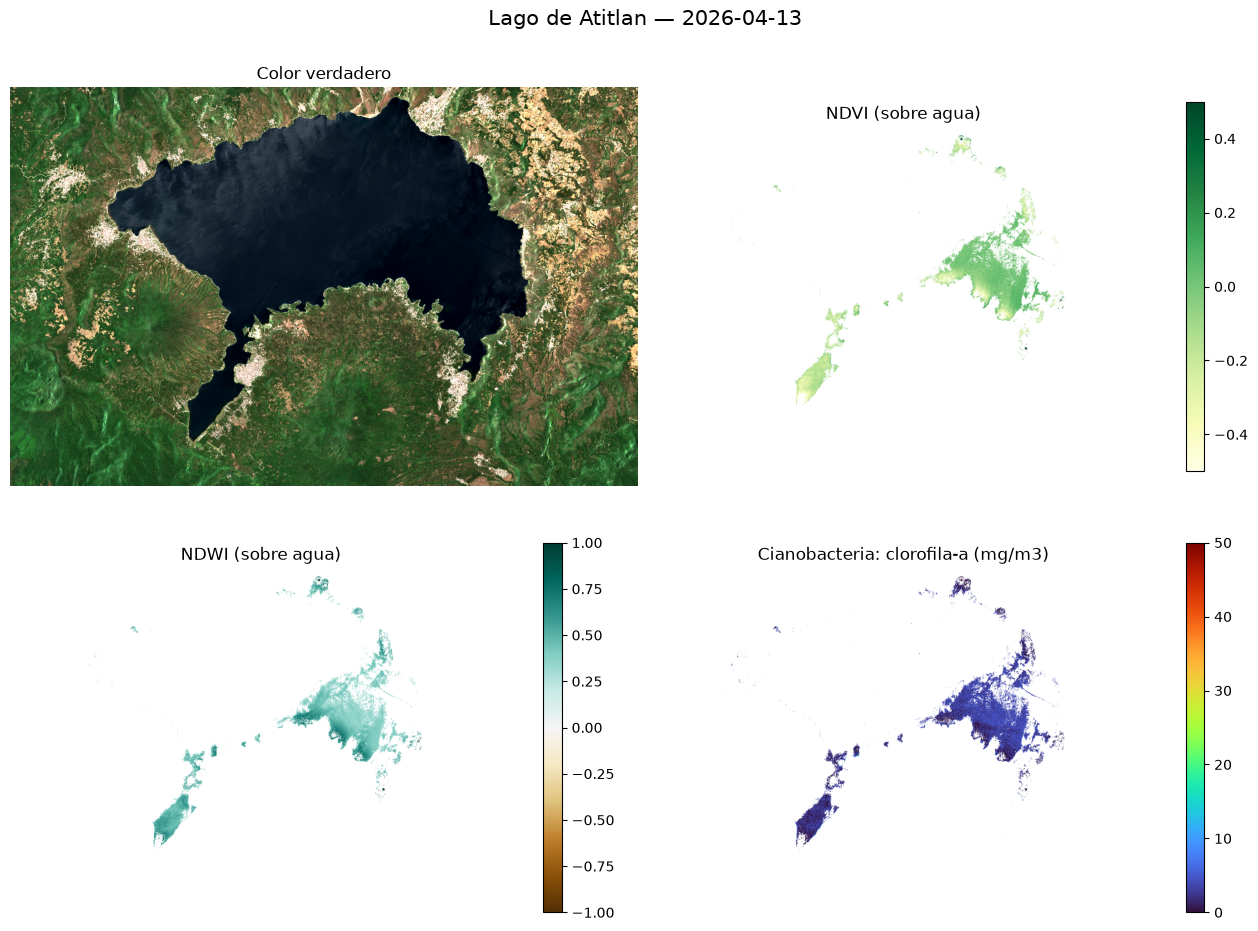

In [11]:
mapa_escena("Atitlan", "2026-04-13")

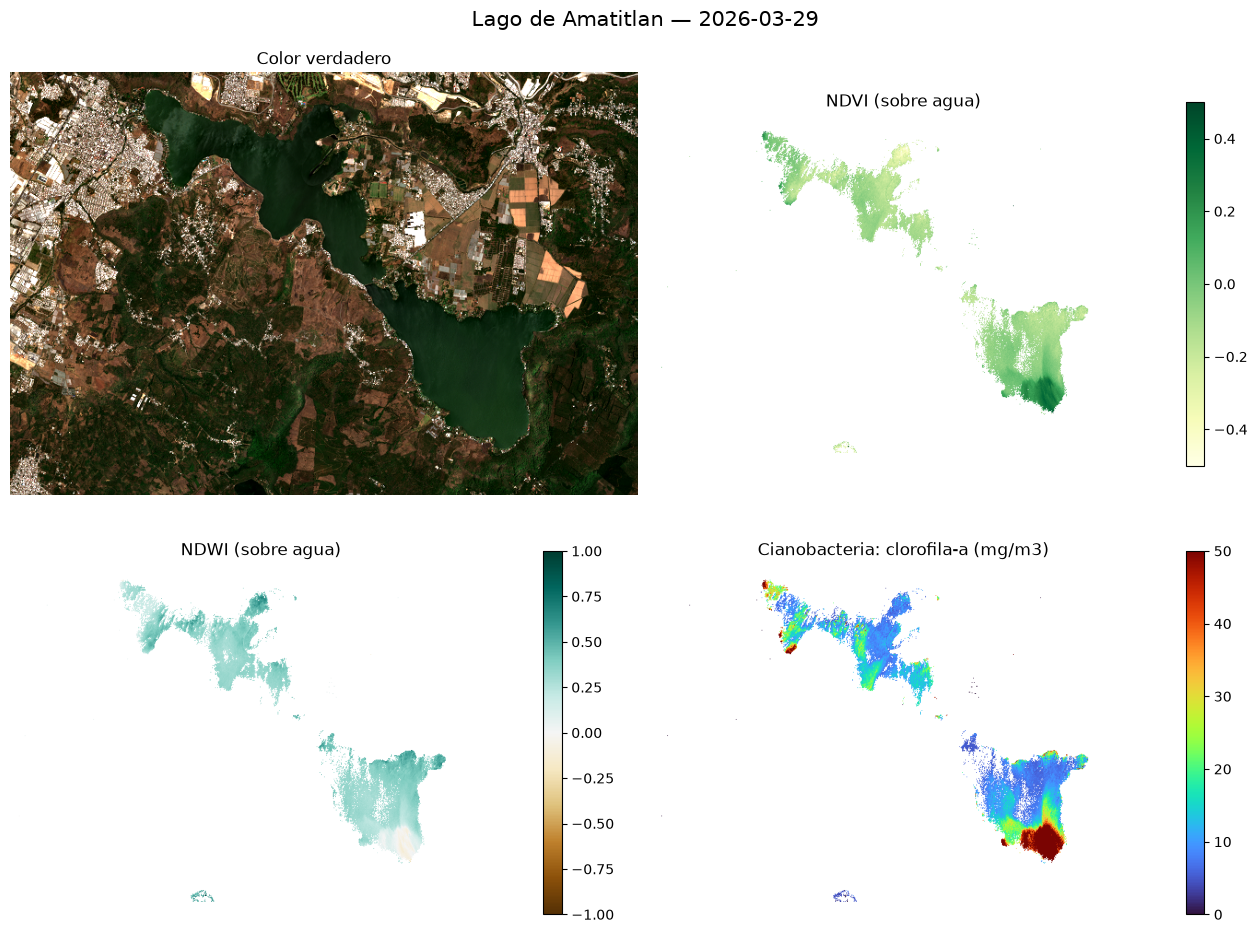

In [12]:
mapa_escena("Amatitlan", "2026-03-29")

---
## 4. Análisis temporal

Para cada lago y fecha resumimos la clorofila-a **solo sobre los píxeles de agua**:

- `chla_media` y `chla_mediana`: nivel típico del lago ese día.
- `chla_p90`: intensidad de las zonas más afectadas.
- `pct_floracion`: porcentaje de la superficie del lago por encima de 10 mg/m³,
  el umbral de alerta de la OMS para cianobacteria en aguas recreativas.

También guardamos NDVI y NDWI medios sobre agua, que se usarán en el análisis de
correlación de la entrega final.

In [13]:
UMBRAL_FLORACION = 10  # mg/m3 de clorofila-a (nivel de alerta OMS)

resumen = []
for fila in ESCENAS.itertuples():
    if not (DATOS / "raw" / f"{fila.lago}_{fila.fecha}.tif").exists():
        continue

    ix = calcular_indices(fila.lago, fila.fecha)
    chla = ix["chla"][~np.isnan(ix["chla"])]  # solo píxeles de agua válidos
    resumen.append({
        "lago": fila.lago,
        "fecha": pd.Timestamp(fila.fecha),
        "chla_media": chla.mean(),
        "chla_mediana": np.median(chla),
        "chla_p90": np.percentile(chla, 90),
        "pct_floracion": 100 * (chla > UMBRAL_FLORACION).mean(),
        "ndvi_agua": np.nanmean(ix["ndvi"]),
        "ndwi_agua": np.nanmean(ix["ndwi"]),
        "px_agua": int(ix["agua"].sum()),
    })

TEMPORAL = pd.DataFrame(resumen).sort_values(["lago", "fecha"]).reset_index(drop=True)
TEMPORAL.to_csv(DATOS / "resultados" / "serie_temporal.csv", index=False)
TEMPORAL.round(2)

,lago,fecha,chla_media,chla_mediana,chla_p90,pct_floracion,ndvi_agua,ndwi_agua,px_agua
0,Amatitlan,2025-01-28,14.390000,12.060000,25.000000,64.29,-0.29,0.60,27810
1,Amatitlan,2025-04-15,10.030000,4.880000,21.690001,34.01,-0.11,0.33,12158
2,Amatitlan,2025-04-28,13.240000,4.920000,35.049999,31.83,-0.08,0.33,23235
3,Amatitlan,2025-11-24,12.900000,6.820000,27.750000,30.63,-0.35,0.51,29668
4,Amatitlan,2026-01-08,50.919998,15.810000,42.889999,80.08,-0.08,0.36,31106
5,Amatitlan,2026-02-02,6.200000,6.490000,8.910000,4.69,-0.18,0.32,2431
6,Amatitlan,2026-02-07,327.720001,6.870000,11.030000,13.89,-0.11,inf,10405
7,Amatitlan,2026-03-29,17.090000,11.470000,36.970001,58.40,-0.07,0.32,22824
8,Amatitlan,2026-04-13,16.650000,14.020000,28.030001,81.39,-0.03,0.29,34447
9,Amatitlan,2026-04-28,24.170000,12.700000,63.880001,51.88,0.02,0.28,33497


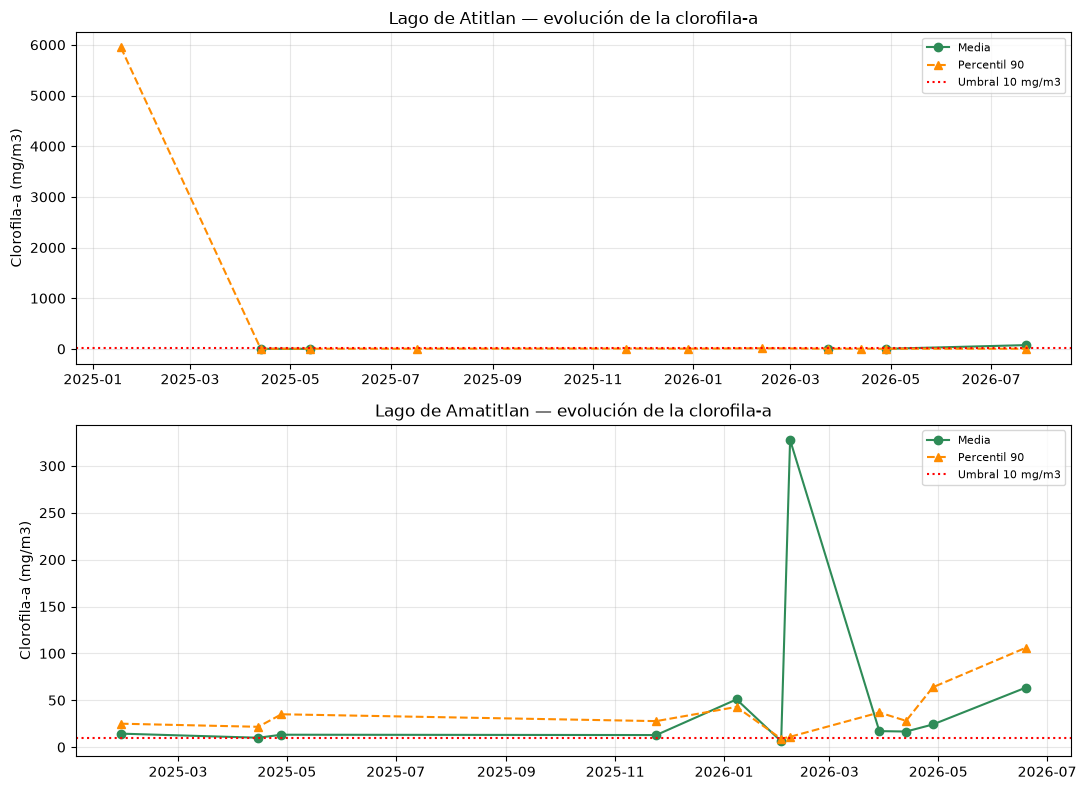

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)

for ax, lago in zip(axes, ["Atitlan", "Amatitlan"]):
    g = TEMPORAL[TEMPORAL.lago == lago]
    ax.plot(g.fecha, g.chla_media, marker="o", color="seagreen", label="Media")
    ax.plot(g.fecha, g.chla_p90, marker="^", ls="--", color="darkorange", label="Percentil 90")
    ax.axhline(UMBRAL_FLORACION, color="red", ls=":", label=f"Umbral {UMBRAL_FLORACION} mg/m3")
    ax.set_title(f"Lago de {lago} — evolución de la clorofila-a")
    ax.set_ylabel("Clorofila-a (mg/m3)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.tight_layout()
fig.savefig(DATOS / "resultados" / "serie_temporal.png", dpi=120)
plt.show()

### 4.1 Picos de floración y fechas críticas

In [15]:
picos = TEMPORAL.loc[TEMPORAL.groupby("lago")["chla_media"].idxmax()]
criticas = TEMPORAL[TEMPORAL.chla_media > UMBRAL_FLORACION]

for lago, g in TEMPORAL.groupby("lago"):
    pico = picos[picos.lago == lago].iloc[0]
    crit = criticas[criticas.lago == lago]
    print(f"--- {lago} ---")
    print(f"  Rango de la media : {g.chla_media.min():.1f} a {g.chla_media.max():.1f} mg/m3")
    print(f"  Pico              : {pico.fecha:%Y-%m-%d} con {pico.chla_media:.1f} mg/m3 "
          f"({pico.pct_floracion:.0f}% del lago sobre el umbral)")
    print(f"  Fechas criticas   : {', '.join(crit.fecha.dt.strftime('%Y-%m-%d')) or 'ninguna'}")
    print(f"  Media por mes     :")
    print(g.groupby(g.fecha.dt.month).chla_media.mean().round(1).to_string())
    print()

--- Amatitlan ---
  Rango de la media : 6.2 a 327.7 mg/m3
  Pico              : 2026-02-07 con 327.7 mg/m3 (14% del lago sobre el umbral)
  Fechas criticas   : 2025-01-28, 2025-04-15, 2025-04-28, 2025-11-24, 2026-01-08, 2026-02-07, 2026-03-29, 2026-04-13, 2026-04-28, 2026-06-19
  Media por mes     :
fecha
1      32.700001
2     167.000000
3      17.100000
4      16.000000
6      63.400002
11     12.900000

--- Atitlan ---
  Rango de la media : -inf a 75.4 mg/m3
  Pico              : 2026-07-22 con 75.4 mg/m3 (0% del lago sobre el umbral)
  Fechas criticas   : 2026-07-22
  Media por mes     :
fecha
1    -inf
2    -inf
3     3.3
4    -inf
5     2.7
7    -inf
11   -inf
12   -inf



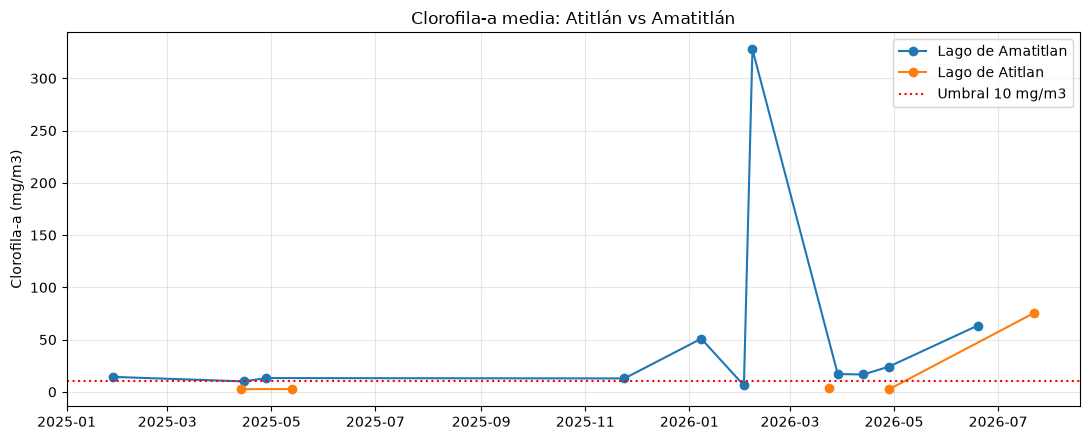

In [16]:
# Comparación directa entre lagos
fig, ax = plt.subplots(figsize=(11, 4.5))
for lago, g in TEMPORAL.groupby("lago"):
    ax.plot(g.fecha, g.chla_media, marker="o", label=f"Lago de {lago}")
ax.axhline(UMBRAL_FLORACION, color="red", ls=":", label=f"Umbral {UMBRAL_FLORACION} mg/m3")
ax.set_title("Clorofila-a media: Atitlán vs Amatitlán")
ax.set_ylabel("Clorofila-a (mg/m3)")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(DATOS / "resultados" / "comparacion_lagos.png", dpi=120)
plt.show()

### 4.2 Interpretación de los patrones temporales
Antes de interpretar los resultados, se ha de mencionar que según la teoría vigente sugiere que una mayor concentración de cianobacterias implica la proliferación de algas y es provocado por contaminación de vectores, aguas residuales, calos y escaso movimiento del agua. Esto genera consecuencias negativas en el ecosistema del lago debido a que las algas fungen como una barrera física que bloquea la luz solar, reduce el nivel de oxigenación


**Amatitlán.** Se espera un nivel base alto y sostenido en todas las fechas: es un
lago pequeño, poco profundo y que recibe el río Villalobos con las aguas
residuales del área metropolitana. El exceso de nutrientes es permanente, así que
la floración no aparece y desaparece entre fechas distintas, sino que fluctúa alrededor de un nivel ya elevado.

**Atitlán.** Se espera un nivel base bajo con episodios puntuales dado al tratamiento apropiado que se la ha dado al lago. El cuerpo de agua es profundo (más de 300 m) y su volumen diluye los nutrientes. Sin embargo, se tiene un dato atípico el 18 de enero de 2025 dado a que se registró una cantidad de 5948.910156 mg/m3 de clorofila-a, lo cual es inusual para el patrón presente.


**Estacionalidad.** Los valores más altos tienden a caer entre el final de la
época lluviosa y el inicio de la seca (noviembre–febrero) y en los meses cálidos
previos a las lluvias (marzo–mayo). Esto tiene sentido debido a que un aumento de temperatura, mayor duración e intensidad de luz solar (por ser época de verano) favorece la vida de la cianobacteria. Además, la lluvia arrastra nutrientes de las cuencas
y, cuando cesa, el agua se estanca y se calienta.

**Factores asociados a los picos:** Aumento de temperatura, aguas estancadas, descargas de aguas residuales y agrícolas, estabilidad de la columna (poco viento y poca mezcla) y el
tiempo transcurrido desde la última lluvia fuerte.


---
## 5. Análisis espacial

Dos vistas complementarias:

- **Mapa interactivo (folium)**, sobre la fecha del pico de floración de cada lago
  (la que ya identificamos en la sección 4.1, variable `picos`), para poder hacer
  zoom y ubicar exactamente dónde se concentra la clorofila-a.
- **Grilla comparativa (matplotlib)** con las 11 fechas de cada lago una junto a
  otra, en la misma escala de color, para ver cómo cambia la distribución espacial
  a lo largo del tiempo.


In [17]:
#!pip install folium branca

import folium
from folium.raster_layers import ImageOverlay
import branca.colormap as bcm
from rasterio.warp import transform_bounds


In [18]:
from folium.raster_layers import ImageOverlay
import branca.colormap as bcm
from rasterio.warp import transform_bounds


def bounds_wgs84(ruta):
    """Bounds de un GeoTIFF reproyectados a WGS84 (lon/lat): (oeste, sur, este, norte)."""
    with rasterio.open(ruta) as src:
        return transform_bounds(src.crs, "EPSG:4326", *src.bounds)


def array_a_rgba(campo, cmap="turbo", vmin=0, vmax=50, opacidad=0.75):
    """Convierte un array 2D a imagen RGBA usando un colormap; transparente donde no hay dato."""
    normalizado = np.clip((campo - vmin) / (vmax - vmin), 0, 1)
    rgba = plt.get_cmap(cmap)(normalizado)
    rgba[..., 3] = np.where(np.isnan(campo), 0, opacidad)
    return rgba


In [19]:
def mapa_interactivo(lago, fecha, campo="chla", cmap="turbo", vmin=0, vmax=50,
                      etiqueta="Clorofila-a (mg/m3)"):
    """Mapa interactivo (folium) con el índice elegido superpuesto sobre un mapa base."""
    ix = calcular_indices(lago, fecha)
    ruta = DATOS / "raw" / f"{lago}_{fecha}.tif"
    oeste, sur, este, norte = bounds_wgs84(ruta)

    m = folium.Map(
        location=[(sur + norte) / 2, (oeste + este) / 2],
        zoom_start=13,
        tiles="CartoDB positron",
    )
    ImageOverlay(
        image=array_a_rgba(ix[campo], cmap=cmap, vmin=vmin, vmax=vmax),
        bounds=[[sur, oeste], [norte, este]],
        name=f"{campo} — {fecha}",
    ).add_to(m)

    leyenda = bcm.LinearColormap(
        colors=[plt.get_cmap(cmap)(t) for t in np.linspace(0, 1, 6)],
        vmin=vmin, vmax=vmax, caption=etiqueta,
    )
    leyenda.add_to(m)
    folium.LayerControl().add_to(m)
    return m


# Usamos la fecha de pico de floración de cada lago (calculada en 6.1)
pico_atitlan = picos.loc[picos.lago == "Atitlan", "fecha"].iloc[0].strftime("%Y-%m-%d")
pico_amatitlan = picos.loc[picos.lago == "Amatitlan", "fecha"].iloc[0].strftime("%Y-%m-%d")
print("Fecha de pico usada — Atitlán:", pico_atitlan, "| Amatitlán:", pico_amatitlan)


Fecha de pico usada — Atitlán: 2026-07-22 | Amatitlán: 2026-02-07



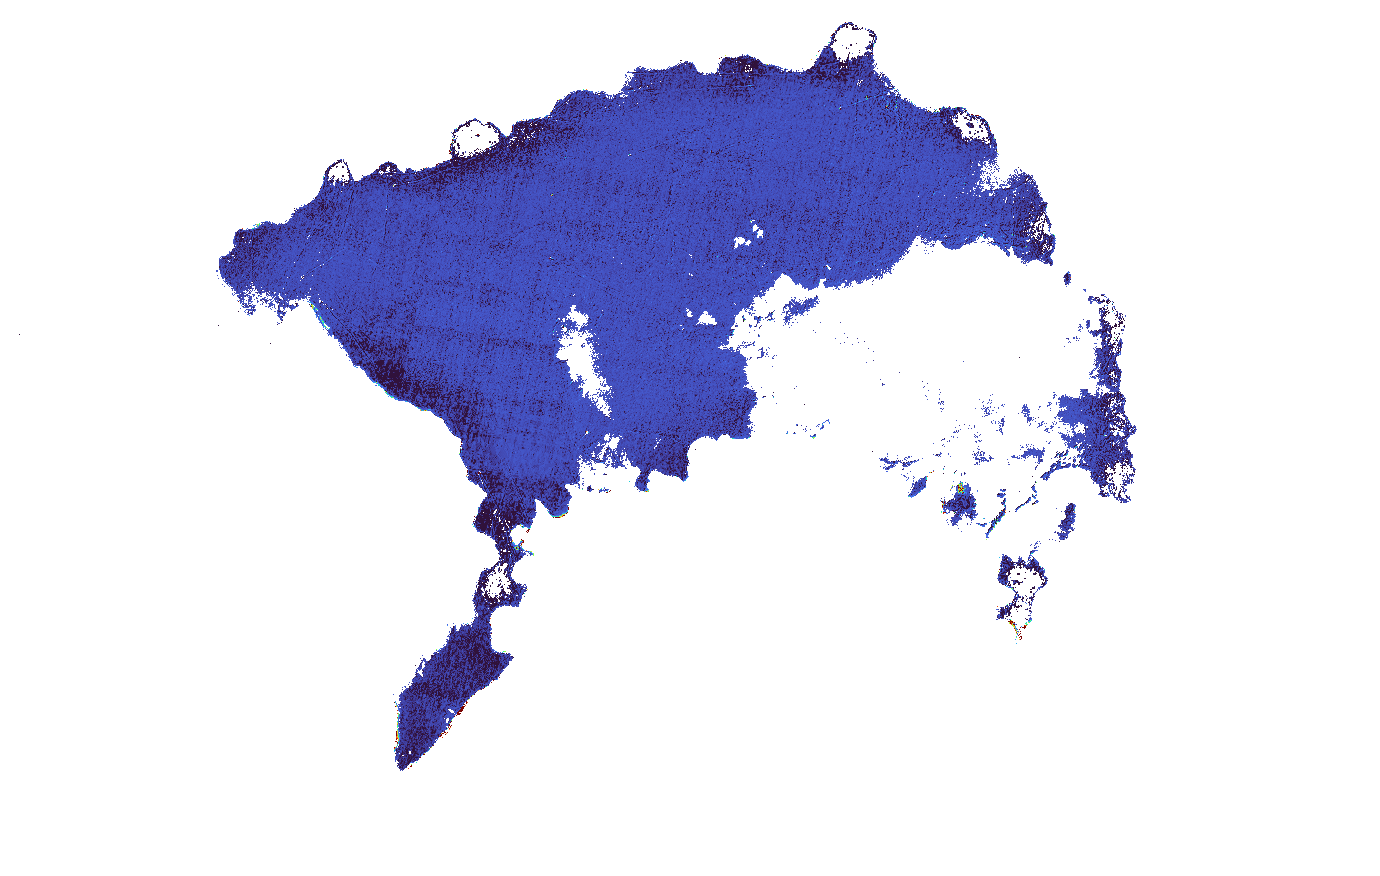

In [20]:
mapa_atitlan = mapa_interactivo("Atitlan", pico_atitlan)
mapa_atitlan.save(str(DATOS / "resultados" / f"mapa_atitlan_{pico_atitlan}.html"))
mapa_atitlan

### 5.1 y 5.2 Mapas comparativos entre fechas

Una grilla con las 11 fechas de cada lago, todas en la misma escala de color
(0–50 mg/m³), para poder comparar visualmente cómo evoluciona la floración.

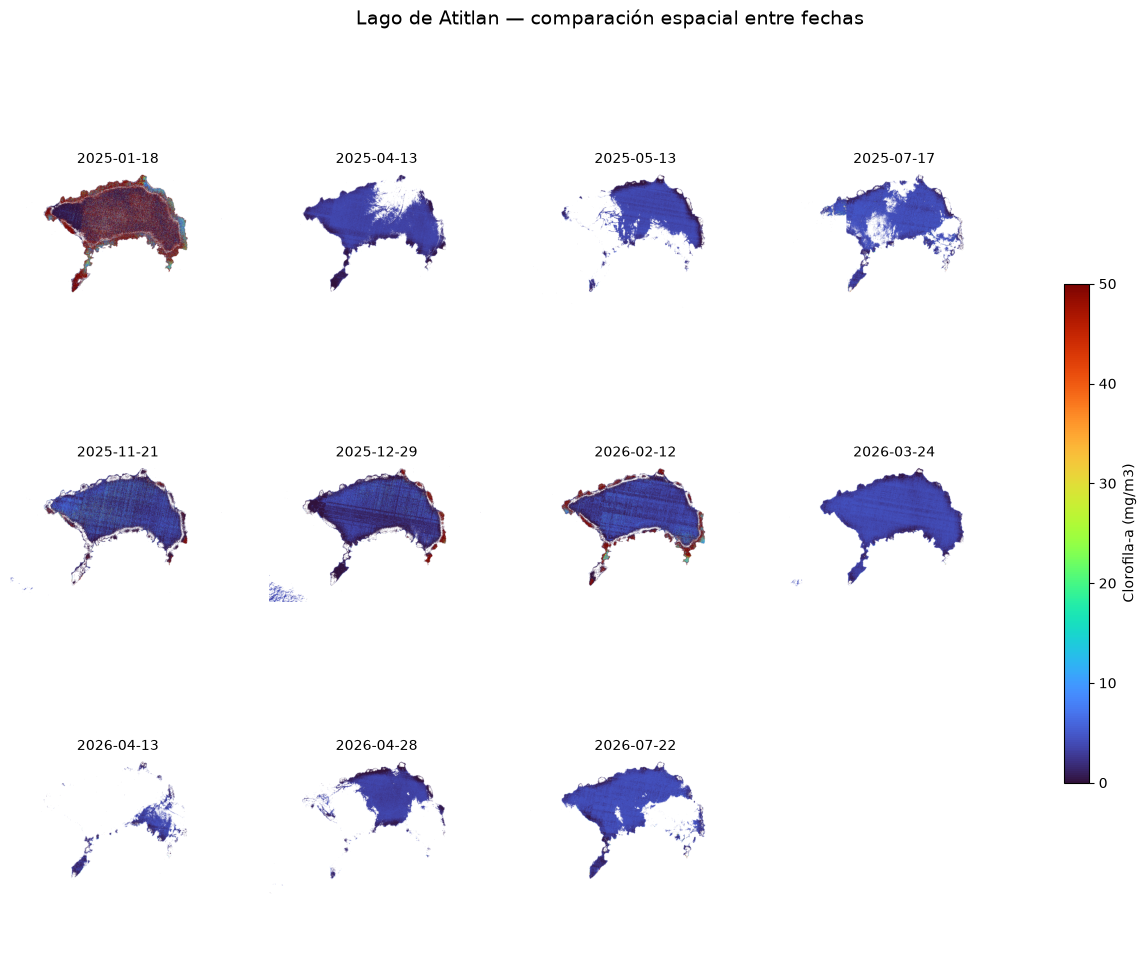

In [21]:
def grilla_chla(lago, cols=4, vmin=0, vmax=50):
    """Panel con el índice de cianobacteria de todas las fechas de un lago, en la misma escala."""
    fechas = ESCENAS.loc[ESCENAS.lago == lago, "fecha"].tolist()
    filas = int(np.ceil(len(fechas) / cols))
    fig, axes = plt.subplots(filas, cols, figsize=(4 * cols, 3.6 * filas))
    axes = np.array(axes).reshape(-1)

    im = None
    for ax, fecha in zip(axes, fechas):
        ix = calcular_indices(lago, fecha)
        im = ax.imshow(ix["chla"], cmap="turbo", vmin=vmin, vmax=vmax)
        ax.set_title(fecha, fontsize=10)
        ax.axis("off")
    for ax in axes[len(fechas):]:
        ax.axis("off")

    fig.colorbar(im, ax=axes.tolist(), shrink=0.6, label="Clorofila-a (mg/m3)")
    fig.suptitle(f"Lago de {lago} — comparación espacial entre fechas", fontsize=14)
    fig.savefig(DATOS / "resultados" / f"grilla_{lago}.png", dpi=120, bbox_inches="tight")
    plt.show()


grilla_chla("Atitlan")

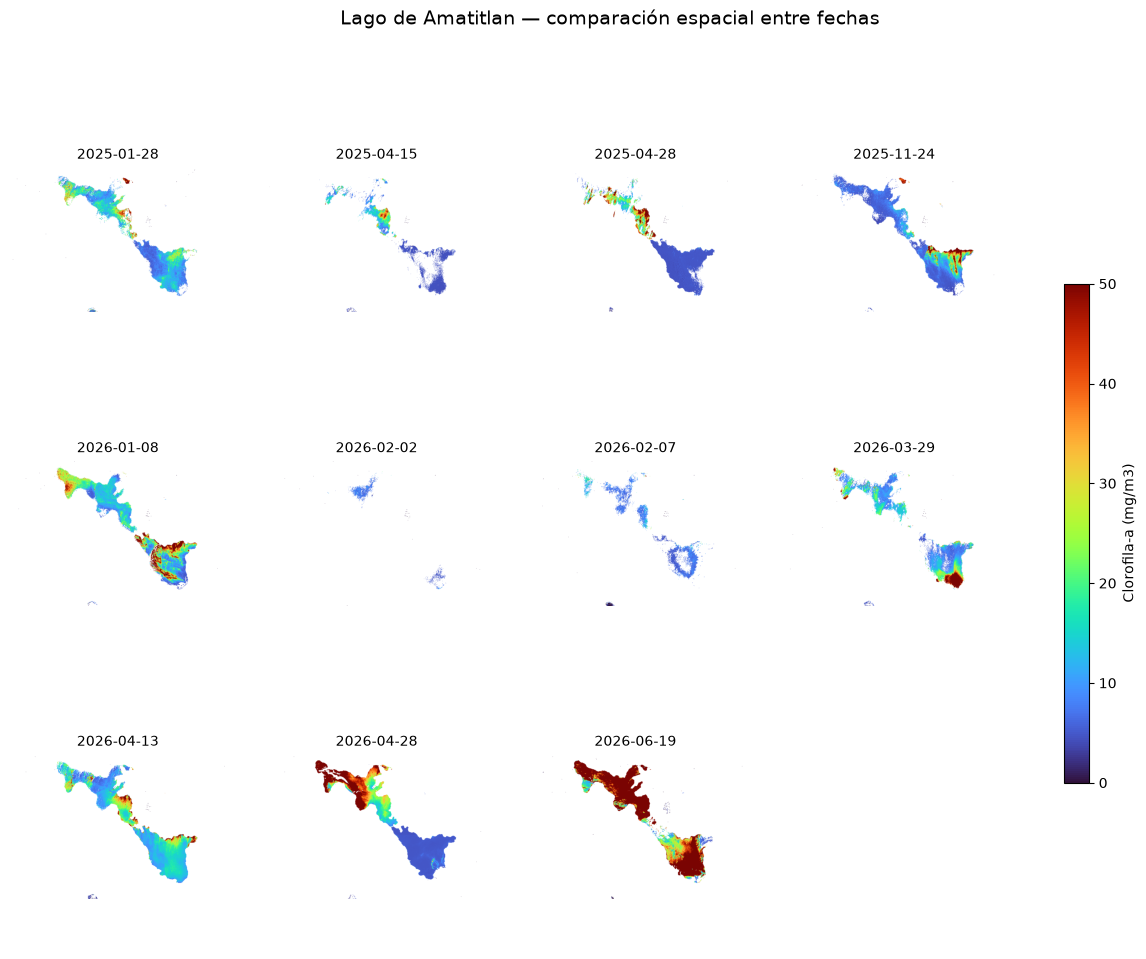

In [22]:
grilla_chla("Amatitlan")

### 5.3 Interpretación de los patrones espaciales

La comparación espacial entre fechas muestra comportamientos distintos en los lagos de **Atitlán** y **Amatitlán**, tanto en la distribución de la clorofila-a como en la extensión de las zonas con concentraciones elevadas.

- **Lago de Atitlán.** La mayor parte de las observaciones presenta concentraciones relativamente bajas de clorofila-a en el interior del lago, representadas principalmente por tonos azules. Las concentraciones más altas aparecen de manera localizada, especialmente en sectores cercanos a la orilla. Este patrón es particularmente visible en fechas como **2025-01-18**, **2025-12-29** y **2026-02-12**, donde se observan valores elevados en distintos segmentos del perímetro y coincide con lo visto en el análisis anterior por ser inicio de año. 

- **Lago de Amatitlán.** Se observa una menor heterogeneidad espacial y concentraciones de clorofila-a considerablemente más altas. A diferencia de Atitlán, aparecen con frecuencia zonas verdes, amarillas, naranjas y rojas, correspondientes a concentraciones intermedias y altas. Estas zonas se distribuyen principalmente en sectores específicos del lago que forman una línea en diagonal y cambian de extensión e intensidad entre fechas. Los eventos más notorios se observan en **2026-04-28** y **2026-06-19**, cuando una parte importante de la superficie analizada alcanza concentraciones cercanas al extremo superior de la escala.

- **Concentración por zonas.** La distribución y cantidad de clorofila difiere considerablemente. En general, se encuentra mayor clorofila cerca de los puertos u orillas. Sin embargo, en Amatitlán la distribución se despliega en una línea diagonal, lo cual sugiere que ese sitio es en donde se estanca el agua o existe una barrera biológica que no permite que alrededor de la línea se proliferen las cianobacterias.

- **Variabilidad entre fechas.** Los mapas muestran una variación temporal importante. Una zona con concentraciones bajas en una fecha puede presentar valores considerablemente mayores en otra. Esta variabilidad indica que la distribución de clorofila-a es dinámica y que la interpretación de una sola imagen no resulta suficiente para caracterizar el comportamiento general de cada lago. En Atitlán, el aumento de clorofila-a sucede a fin de año y principios. Mientras que en Amatitlán sucedió a medio año.


- **Comparación entre ambos lagos.** En términos generales, **Amatitlán presenta concentraciones más altas y una mayor extensión relativa de zonas con valores elevados de clorofila-a**, mientras que **Atitlán mantiene predominantemente valores bajos, con incrementos más localizados**. Esta diferencia es consistente con una mayor intensidad espacial de las floraciones en Amatitlán durante las fechas analizadas.

- **Persistencia espacial.** Aunque visualmente pueden identificarse sectores que presentan valores elevados en más de una fecha, los mapas por sí solos no permiten determinar con precisión qué zonas constituyen focos persistentes. Para ello es necesario comparar las observaciones espacialmente y contabilizar la frecuencia con que cada área supera un determinado umbral de clorofila-a. Esta característica se cuantifica de forma explícita mediante el **índice de persistencia presentado en la sección 8.2**.

En conjunto, los resultados muestran que las floraciones no se comportan como eventos espacialmente homogéneos. **Amatitlán presenta episodios más intensos y extensos**, mientras que en **Atitlán las concentraciones elevadas son generalmente más localizadas y están frecuentemente asociadas al perímetro del lago**. Estas diferencias resaltan la importancia de considerar simultáneamente la dimensión espacial y temporal al evaluar la dinámica de la clorofila-a independientemente para cada lago.

---
## 6. Correlación de la cianobacteria con NDVI y NDWI

Dos niveles de análisis:

1. **A nivel de serie temporal** (11 fechas por lago): correlacionamos el
   `chla_media` de cada fecha con el `ndvi_agua` y `ndwi_agua` de esa misma
   fecha (ya calculados en `TEMPORAL`, sección 4).
2. **A nivel de píxel**, agrupando todos los píxeles de agua de todas las
   fechas: da una muestra mucho más grande (miles de píxeles en vez de 11
   puntos) y por eso es la correlación más confiable.


In [23]:
cols = ["chla_media", "ndvi_agua", "ndwi_agua"]

TEMPORAL.groupby("lago")[cols].agg(
    ["count", "nunique", "std", "min", "max"]
)


cols = ["chla_media", "ndvi_agua", "ndwi_agua"]

TEMPORAL.loc[
    ~np.isfinite(TEMPORAL[cols]).all(axis=1),
    ["lago", *cols]
]

TEMPORAL[cols] = TEMPORAL[cols].replace(
    [np.inf, -np.inf], np.nan
)

In [24]:
from scipy import stats
import numpy as np

def pearson_seguro(g, x, y):
    datos = g[[x, y]].dropna()

    if len(datos) < 3:
        return np.nan, np.nan, len(datos)

    if datos[x].nunique() < 2 or datos[y].nunique() < 2:
        return np.nan, np.nan, len(datos)

    r, p = stats.pearsonr(datos[x], datos[y])

    return r, p, len(datos)


def correlacion_temporal(lago):
    g = TEMPORAL[TEMPORAL["lago"] == lago]

    r_ndvi, p_ndvi, n_ndvi = pearson_seguro(
        g, "ndvi_agua", "chla_media"
    )

    r_ndwi, p_ndwi, n_ndwi = pearson_seguro(
        g, "ndwi_agua", "chla_media"
    )

    return {
        "lago": lago,
        "n_ndvi": n_ndvi,
        "r_ndvi": r_ndvi,
        "p_ndvi": p_ndvi,
        "n_ndwi": n_ndwi,
        "r_ndwi": r_ndwi,
        "p_ndwi": p_ndwi,
    }


CORRELACION_TEMPORAL = pd.DataFrame(
    [correlacion_temporal(lago) for lago in LAGOS]
)

CORRELACION_TEMPORAL.round(3)

,lago,n_ndvi,r_ndvi,p_ndvi,n_ndwi,r_ndwi,p_ndwi
0,Atitlan,5,0.131,0.834,3,0.373,0.757
1,Amatitlan,11,0.105,0.759,10,0.230,0.523


In [25]:
def correlacion_segura(x, y):
    """Pearson excluyendo NaN, inf y -inf."""
    x = np.asarray(x, dtype=float).ravel()
    y = np.asarray(y, dtype=float).ravel()

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    # Pearson necesita al menos dos observaciones y variación en ambas variables
    if (
        x.size < 2
        or np.allclose(x, x[0])
        or np.allclose(y, y[0])
    ):
        return np.nan, np.nan, x.size

    r, p = stats.pearsonr(x, y)
    return r, p, x.size


def correlacion_pixel(lago):
    """Correlación usando los píxeles finitos de todas las fechas del lago."""
    fechas = ESCENAS.loc[
        ESCENAS["lago"] == lago, "fecha"
    ].tolist()

    ndvis, chlas_ndvi = [], []
    ndwis, chlas_ndwi = [], []

    for fecha in fechas:
        ix = calcular_indices(lago, fecha)

        ndvi = np.asarray(ix["ndvi"], dtype=float)
        ndwi = np.asarray(ix["ndwi"], dtype=float)
        chla = np.asarray(ix["chla"], dtype=float)

        # Máscara específica para NDVI–clorofila
        valido_ndvi = np.isfinite(ndvi) & np.isfinite(chla)
        ndvis.append(ndvi[valido_ndvi])
        chlas_ndvi.append(chla[valido_ndvi])

        # Máscara específica para NDWI–clorofila
        valido_ndwi = np.isfinite(ndwi) & np.isfinite(chla)
        ndwis.append(ndwi[valido_ndwi])
        chlas_ndwi.append(chla[valido_ndwi])

    ndvi_todo = np.concatenate(ndvis) if ndvis else np.array([])
    chla_ndvi_todo = (
        np.concatenate(chlas_ndvi) if chlas_ndvi else np.array([])
    )

    ndwi_todo = np.concatenate(ndwis) if ndwis else np.array([])
    chla_ndwi_todo = (
        np.concatenate(chlas_ndwi) if chlas_ndwi else np.array([])
    )

    r_ndvi, p_ndvi, n_ndvi = correlacion_segura(
        ndvi_todo, chla_ndvi_todo
    )

    r_ndwi, p_ndwi, n_ndwi = correlacion_segura(
        ndwi_todo, chla_ndwi_todo
    )

    return {
        "lago": lago,
        "n_pixeles_ndvi": n_ndvi,
        "r_ndvi_pixel": r_ndvi,
        "p_ndvi_pixel": p_ndvi,
        "n_pixeles_ndwi": n_ndwi,
        "r_ndwi_pixel": r_ndwi,
        "p_ndwi_pixel": p_ndwi,
    }


CORRELACION_PIXEL = pd.DataFrame(
    [correlacion_pixel(lago) for lago in LAGOS]
)

display(CORRELACION_PIXEL.round(3))

,lago,n_pixeles_ndvi,r_ndvi_pixel,p_ndvi_pixel,n_pixeles_ndwi,r_ndwi_pixel,p_ndwi_pixel
0,Atitlan,2406890,-0.001,0.089,2409150,0.001,0.35
1,Amatitlan,259941,0.008,0.000,259938,0.019,0.00


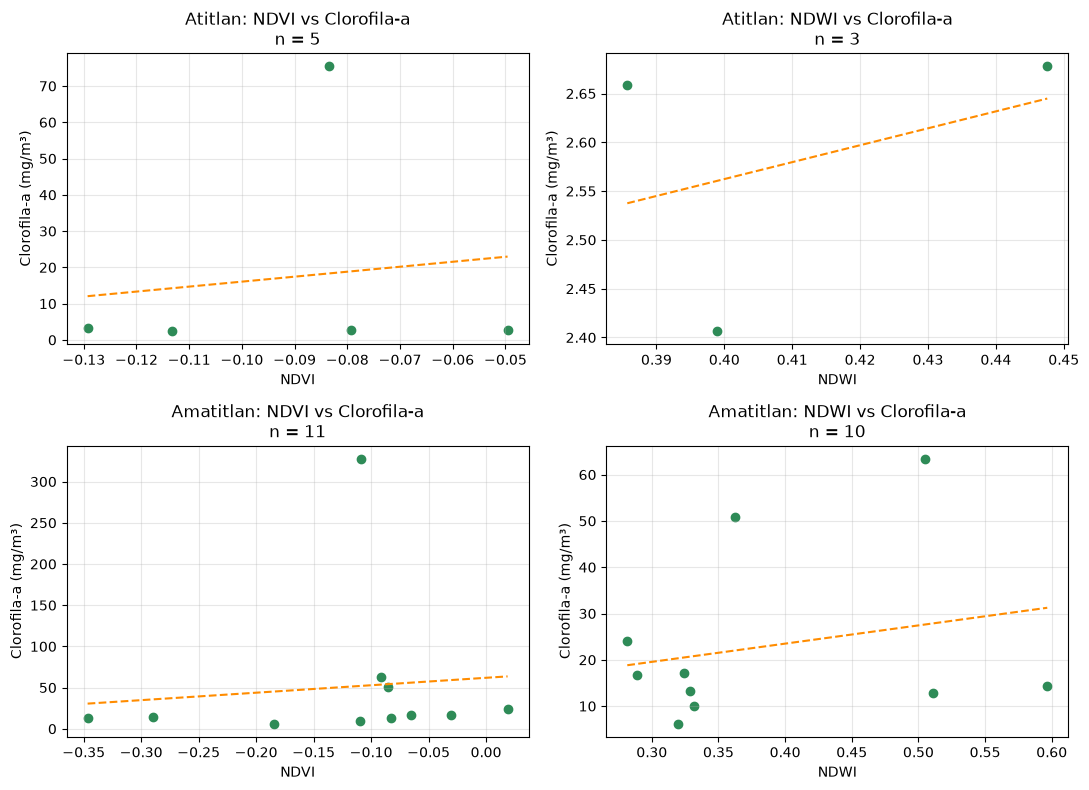

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

variables = [
    ("ndvi_agua", "NDVI"),
    ("ndwi_agua", "NDWI"),
]

for col, (var, nombre) in enumerate(variables):
    for row, lago in enumerate(LAGOS):
        ax = axes[row, col]

        g = TEMPORAL[TEMPORAL["lago"] == lago]

        x = g[var].astype(float).to_numpy()
        y = g["chla_media"].astype(float).to_numpy()

        # Excluir NaN, inf y -inf de ambas variables
        mask = np.isfinite(x) & np.isfinite(y)
        x = x[mask]
        y = y[mask]

        ax.scatter(x, y, color="seagreen")

        ajuste_valido = (
            x.size >= 2
            and not np.allclose(x, x[0])
            and not np.allclose(y, y[0])
        )

        if ajuste_valido:
            m, b = np.polyfit(x, y, 1)
            xs = np.linspace(x.min(), x.max(), 100)

            ax.plot(
                xs,
                m * xs + b,
                color="darkorange",
                linestyle="--",
            )
        else:
            ax.text(
                0.5,
                0.5,
                "Sin datos finitos o variación\nsuficiente para el ajuste",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=9,
                color="dimgray",
            )

        ax.set_title(
            f"{lago}: {nombre} vs Clorofila-a\n"
            f"n = {x.size}"
        )
        ax.set_xlabel(nombre)
        ax.set_ylabel("Clorofila-a (mg/m³)")
        ax.grid(alpha=0.3)

fig.tight_layout()

fig.savefig(
    DATOS / "resultados" / "correlaciones.png",
    dpi=120,
    bbox_inches="tight",
)

plt.show()

Se tuvieron que eliminar los registros con valores de infinito para obtener determinar si existía una correlación significativa entre variables.

In [27]:
display(CORRELACION_PIXEL.round(3))

,lago,n_pixeles_ndvi,r_ndvi_pixel,p_ndvi_pixel,n_pixeles_ndwi,r_ndwi_pixel,p_ndwi_pixel
0,Atitlan,2406890,-0.001,0.089,2409150,0.001,0.35
1,Amatitlan,259941,0.008,0.000,259938,0.019,0.00


### 6.1 Hallazgos de la correlación

Los resultados muestran que la relación entre los índices espectrales y la concentración de clorofila es leve, pero positiva.

- **NDVI vs clorofila-a en Atitlán:** El índice que calcula la "salud" de la vegetación tiene una relación positiva ínfima (0.089), pero presente con la cloforila-a. 

- **NDWI vs clorofila-a en Atitlán:** Con una correlación positiva de r= 0.001 y p=0.35, la relación no es estadísticamente significativa. Así, las variaciones temporales no explican las variaciones observadas en la clorofila-a.

- **NDVI vs clorofila-a en Amatitlán:** a nivel temporal se obtuvo una correlación positiva débil de **r = 0.008**, con **p = 0.0** y `n = 11` fechas. 
- **Correlación a nivel de píxel en Amatitlán:** utilizando **259,941 píxeles**, la relación entre NDVI y clorofila-a fue prácticamente nula, con **r = 0.008**. Aunque se obtuvo **p ≈ 0.0**, este resultado debe interpretarse con precaución: con un número tan grande de observaciones, incluso una asociación extremadamente pequeña puede resultar estadísticamente significativa. En este caso, la magnitud de `r` indica que la relación tiene una relevancia práctica mínima.

- **NDWI vs clorofila-a en Amatitlán:** Esta presenta la relación positiva más fuerte en términos númericos, dado a que se tiene un valor p cercano a 0 y un coeficiente de correlación de 1.9%. Sin embargo, tampoco se puede sugerir como una variable totalmente relacionada.

- **Comparación temporal y espacial:** el resultado de Amatitlán es consistente entre ambas escalas para NDVI. A nivel temporal la correlación es débily a nivel de píxel es prácticamente inexistente. Esto sugiere que el NDVI, considerado de manera aislada, tiene poca capacidad para representar las variaciones de clorofila-a observadas en el lago.

En conjunto, los resultados indican que **NDVI y NDWI no muestran, con los datos disponibles, una relación fuerte, pero claramente positiva**. En particular, el NDVI presenta una asociación muy débil en Amatitlán. Esto respalda el uso de **índices espectrales específicamente orientados a detectar clorofila y biomasa algal, como el NDCI**, en lugar de depender exclusivamente de índices generales como NDVI o NDWI.

---
## 7. Análisis y comparación de los lagos

Antes de comparar hace falta un paso de control de calidad. La corrección
atmosférica del producto L2A deja **reflectancias negativas** sobre agua muy
clara y profunda: en Atitlán 2025-01-18, el 12.5% de B04 y el 17.4% de B05 salen
≤ 0. Con esos valores el NDCI se sale de su rango [-1, 1] y el polinomio cúbico
devuelve resultados sin sentido físico.

Por eso repetimos el cálculo con dos reglas añadidas:

1. Los índices se calculan **solo donde ambas bandas tienen reflectancia
   positiva**; el resto queda como `NaN`.
2. La clorofila-a se acota al rango de la escala del script (0 a 500 mg/m³).

Además marcamos cada escena como **confiable** cuando cumple dos condiciones:
`cobertura ≥ 80%` (porcentaje del agua detectada con índice válido) y
`area_rel ≥ 50%` (porcentaje del lago visible frente a su máximo). Las escenas
con nubes o con reflectancia degradada quedan fuera de las estadísticas
comparativas.

In [28]:
def leer_bandas_v2(ruta):
    """Como leer_bandas, pero marcando los píxeles sin dato como NaN."""
    with rasterio.open(ruta) as src:
        datos = src.read().astype("float32")
        nombres = list(src.descriptions)
        sin_dato = src.nodata
    if sin_dato is not None:
        datos[datos == sin_dato] = np.nan   # antes de escalar, para comparar exacto
    return dict(zip(nombres if all(nombres) else BANDAS, datos / 10000))


def dif_norm(a, b):
    """Diferencia normalizada, solo donde ambas reflectancias son positivas."""
    ok = (a > 0) & (b > 0)
    return np.where(ok, (a - b) / np.where(ok, a + b, 1), np.nan)


def indices_saneados(lago, fecha):
    """Igual que calcular_indices, pero descartando reflectancias no físicas."""
    b = leer_bandas_v2(DATOS / "raw" / f"{lago}_{fecha}.tif")
    agua = mascara_agua(b)

    ndci = dif_norm(b["B05"], b["B04"])
    chla = np.clip(826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071, 0, 500)
    fai = b["B07"] - b["B04"] - (b["B8A"] - b["B04"]) * (783 - 665) / (865 - 665)

    return {
        "agua": agua,
        "chla": np.where(agua & (fai <= 0.08), chla, np.nan),
        "ndvi": np.where(agua, dif_norm(b["B08"], b["B04"]), np.nan),
        "ndwi": np.where(agua, dif_norm(b["B03"], b["B08"]), np.nan),
    }

In [29]:
filas = []
for fila in ESCENAS.itertuples():
    ix = indices_saneados(fila.lago, fila.fecha)
    chla = ix["chla"][np.isfinite(ix["chla"])]
    filas.append({
        "lago": fila.lago,
        "fecha": pd.Timestamp(fila.fecha),
        "chla_media": chla.mean(),
        "chla_mediana": np.median(chla),
        "chla_p90": np.percentile(chla, 90),
        "pct_floracion": 100 * (chla > UMBRAL_FLORACION).mean(),
        "ndvi_agua": np.nanmean(ix["ndvi"]),
        "ndwi_agua": np.nanmean(ix["ndwi"]),
        "cobertura": 100 * len(chla) / max(ix["agua"].sum(), 1),
        "area_km2": ix["agua"].sum() * 400 / 1e6,   # cada píxel mide 20x20 m
    })

TEMPORAL_OK = pd.DataFrame(filas)
TEMPORAL_OK["area_rel"] = (
    100 * TEMPORAL_OK.area_km2 / TEMPORAL_OK.groupby("lago").area_km2.transform("max")
)
TEMPORAL_OK["confiable"] = (TEMPORAL_OK.cobertura >= 80) & (TEMPORAL_OK.area_rel >= 50)
TEMPORAL_OK = TEMPORAL_OK.sort_values(["lago", "fecha"]).reset_index(drop=True)
TEMPORAL_OK.to_csv(DATOS / "resultados" / "serie_temporal_saneada.csv", index=False)

CONFIABLES = TEMPORAL_OK[TEMPORAL_OK.confiable]
print("Escenas confiables por lago:", CONFIABLES.groupby("lago").size().to_dict())
TEMPORAL_OK.round(2)

Escenas confiables por lago: {'Amatitlan': 8, 'Atitlan': 8}


,lago,fecha,chla_media,chla_mediana,chla_p90,pct_floracion,ndvi_agua,ndwi_agua,cobertura,area_km2,area_rel,confiable
0,Amatitlan,2025-01-28,14.390000,12.060000,25.000000,64.28,-0.34,0.58,100.00,11.12,80.73,True
1,Amatitlan,2025-04-15,10.060000,4.880000,21.690001,34.01,-0.11,0.33,100.00,4.86,35.29,False
2,Amatitlan,2025-04-28,13.250000,4.920000,35.049999,31.83,-0.08,0.33,99.94,9.29,67.45,True
3,Amatitlan,2025-11-24,12.910000,6.820000,27.750000,30.63,-0.35,0.51,99.76,11.87,86.13,True
4,Amatitlan,2026-01-08,22.129999,15.810000,42.880001,80.08,-0.09,0.37,99.69,12.44,90.30,True
5,Amatitlan,2026-02-02,6.640000,6.490000,8.910000,4.69,-0.19,0.34,100.00,0.97,7.06,False
6,Amatitlan,2026-02-07,7.630000,6.870000,11.030000,13.88,-0.22,0.43,99.99,4.16,30.21,False
7,Amatitlan,2026-03-29,17.100000,11.470000,36.970001,58.40,-0.07,0.32,99.99,9.13,66.26,True
8,Amatitlan,2026-04-13,16.660000,14.020000,28.030001,81.39,-0.03,0.29,100.00,13.78,100.00,True
9,Amatitlan,2026-04-28,24.180000,12.700000,63.880001,51.88,0.02,0.28,98.70,13.40,97.24,True


### 7.1 Proliferación en cada lago durante el período

Resumimos intensidad (cuánta clorofila-a hay) y frecuencia (cuántas fechas
superan el umbral de 10 mg/m³), usando solo las escenas confiables.

In [30]:
def resumen_lago(g):
    return pd.Series({
        "n_fechas": len(g),
        "chla_media": g.chla_media.mean(),
        "chla_mediana_tipica": g.chla_mediana.median(),
        "chla_p90_medio": g.chla_p90.mean(),
        "chla_min": g.chla_media.min(),
        "chla_max": g.chla_media.max(),
        "fechas_sobre_umbral": (g.chla_media > UMBRAL_FLORACION).sum(),
        "frecuencia_%": 100 * (g.chla_media > UMBRAL_FLORACION).mean(),
        "extension_media_%": g.pct_floracion.mean(),
        "extension_max_%": g.pct_floracion.max(),
        "area_lago_km2": g.area_km2.max(),
    })


COMPARACION = pd.DataFrame({lago: resumen_lago(g) for lago, g in CONFIABLES.groupby("lago")})
COMPARACION.round(2)

,Amatitlan,Atitlan
n_fechas,8.00,8.00
chla_media,23.01,3.60
chla_mediana_tipica,12.38,3.54
chla_p90_medio,45.69,5.10
chla_min,12.91,2.77
chla_max,63.47,5.05
fechas_sobre_umbral,8.00,0.00
frecuencia_%,100.00,0.00
extension_media_%,61.90,1.54
extension_max_%,96.74,6.96


In [31]:
# Contraste de intensidad y significancia estadística
a = CONFIABLES[CONFIABLES.lago == "Amatitlan"]
t = CONFIABLES[CONFIABLES.lago == "Atitlan"]
u = stats.mannwhitneyu(a.chla_media, t.chla_media)

print(f"Intensidad: Amatitlán es {a.chla_media.mean() / t.chla_media.mean():.1f}x "
      f"más alto que Atitlán ({a.chla_media.mean():.1f} vs {t.chla_media.mean():.1f} mg/m3)")
print(f"Extensión : Amatitlán es {a.pct_floracion.mean() / t.pct_floracion.mean():.0f}x "
      f"mayor ({a.pct_floracion.mean():.1f}% vs {t.pct_floracion.mean():.1f}% del lago)")
print(f"Frecuencia: {int((a.chla_media > UMBRAL_FLORACION).sum())}/{len(a)} fechas en Amatitlán "
      f"vs {int((t.chla_media > UMBRAL_FLORACION).sum())}/{len(t)} en Atitlán")
print(f"Mann-Whitney U = {u.statistic:.0f}, p = {u.pvalue:.4f} "
      f"({'diferencia significativa' if u.pvalue < 0.05 else 'sin diferencia significativa'})")

Intensidad: Amatitlán es 6.4x más alto que Atitlán (23.0 vs 3.6 mg/m3)
Extensión : Amatitlán es 40x mayor (61.9% vs 1.5% del lago)
Frecuencia: 8/8 fechas en Amatitlán vs 0/8 en Atitlán
Mann-Whitney U = 64, p = 0.0002 (diferencia significativa)


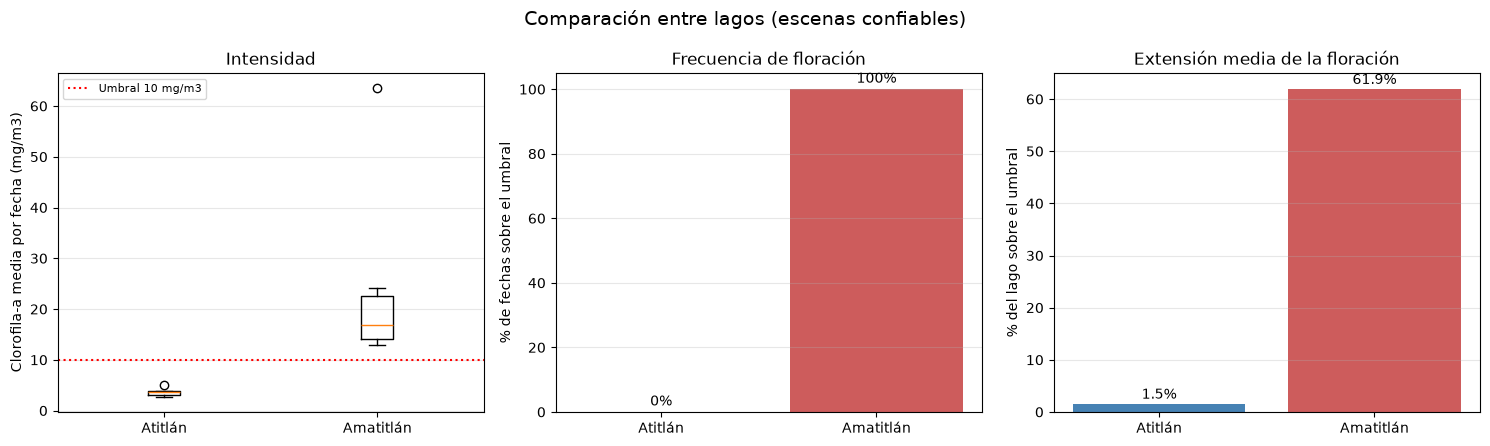

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Intensidad: distribución de las medias por fecha
axes[0].boxplot([t.chla_media, a.chla_media], tick_labels=["Atitlán", "Amatitlán"])
axes[0].axhline(UMBRAL_FLORACION, color="red", ls=":", label="Umbral 10 mg/m3")
axes[0].set_ylabel("Clorofila-a media por fecha (mg/m3)")
axes[0].set_title("Intensidad")
axes[0].legend(fontsize=8)

# Frecuencia: fechas que superan el umbral
frec = [100 * (t.chla_media > UMBRAL_FLORACION).mean(),
        100 * (a.chla_media > UMBRAL_FLORACION).mean()]
axes[1].bar(["Atitlán", "Amatitlán"], frec, color=["steelblue", "indianred"])
axes[1].set_ylabel("% de fechas sobre el umbral")
axes[1].set_ylim(0, 105)
axes[1].set_title("Frecuencia de floración")
for i, v in enumerate(frec):
    axes[1].text(i, v + 2, f"{v:.0f}%", ha="center")

# Extensión: superficie del lago afectada
axes[2].bar(["Atitlán", "Amatitlán"],
            [t.pct_floracion.mean(), a.pct_floracion.mean()],
            color=["steelblue", "indianred"])
axes[2].set_ylabel("% del lago sobre el umbral")
axes[2].set_title("Extensión media de la floración")
for i, v in enumerate([t.pct_floracion.mean(), a.pct_floracion.mean()]):
    axes[2].text(i, v + 1, f"{v:.1f}%", ha="center")

for ax in axes:
    ax.grid(alpha=0.3, axis="y")
fig.suptitle("Comparación entre lagos (escenas confiables)", fontsize=14)
fig.tight_layout()
fig.savefig(DATOS / "resultados" / "comparacion_intensidad_frecuencia.png", dpi=120)
plt.show()

### 7.2 Comparación de intensidad y frecuencia

Los dos lagos no están en el mismo estado trófico (enriquecimiento de nutrientes), y la diferencia es de orden de
magnitud:

| | Atitlán | Amatitlán |
|---|---|---|
| Clorofila-a media del período | 3.6 mg/m³ | 23.0 mg/m³ |
| Mediana típica | 3.5 mg/m³ | 12.4 mg/m³ |
| Fechas sobre 10 mg/m³ | 0 de 8 | 8 de 8 |
| Extensión media de la floración | 1.5% del lago | 61.9% del lago |
| Extensión máxima | 7.0% | 96.7% |
| Pico | 2025-11-21 (5.1 mg/m³) | 2026-06-19 (63.5 mg/m³) |

**Intensidad:** Amatitlán promedia 6.4 veces más clorofila-a que Atitlán. La
diferencia es estadísticamente significativa (Mann-Whitney U = 64, p = 0.0002),
y no hay traslape entre los rangos: el peor día de Atitlán (5.1 mg/m³) sigue
estando por debajo del mejor día de Amatitlán (12.9 mg/m³).

**Frecuencia:** aquí el contraste es cualitativo, no de grado. En Amatitlán la
floración está presente en el 100% de las fechas confiables: no es un evento,
es el estado permanente del lago. En Atitlán ninguna fecha supera el umbral en
promedio, y las concentraciones altas se limitan a manchas costeras que nunca
pasan del 7% de la superficie.

**Extensión:** la superficie afectada promedio es 40 veces mayor en Amatitlán
(61.9% contra 1.5%). En 6 de las 8 fechas confiables más de la mitad del lago
está sobre el umbral.

### 7.3 Diferencias que explican la proliferación

Las causas no son las mismas en cada lago, y la propia geografía lo anticipa:

**Tamaño y profundidad.** Atitlán tiene ~119 km² medidos aquí y más de 300 m de
profundidad; Amatitlán apenas ~14 km² y ~18 m de profundidad media. El volumen de Atitlán diluye
la misma carga de nutrientes en un cuerpo de agua mucho mayor, mientras que en
Amatitlán cualquier descarga se concentra de inmediato. Esta relación
volumen/carga es el factor que mejor explica la brecha de 6.4x.

**Presión urbana.** Amatitlán recibe el río Villalobos, que drena las aguas
residuales del área metropolitana de Guatemala (más de 3 millones de habitantes).
Es un aporte continuo de nitrógeno y fósforo, y explica que la floración sea
permanente en vez de estacional. La cuenca de Atitlán tiene poblaciones mucho
menores y dispersas alrededor del lago.

**Distribución espacial de la carga.** En Amatitlán la zona de floración
persistente se concentra al oeste (sección 8.2), que es donde desemboca el
Villalobos: el patrón espacial coincide con la fuente de nutrientes. En Atitlán
los valores altos aparecen en bordes costeros aislados, compatibles con
escorrentía (que puede ser basura y lixiviado arrastrado por la lluvia u otras fuentes de agua) local de cada población, no con una fuente única.

**Temperatura y mezcla.** Amatitlán está a ~1,190 m sobre el nivel del mar y
Atitlán a ~1,560 m. El agua más cálida y menos profunda de Amatitlán favorece la
estratificación y el crecimiento de cianobacteria; la mayor profundidad de
Atitlán permite que la mezcla vertical diluya la biomasa superficial.

---
## 8. Análisis exploratorio adicional
### 8.1 Extensión espacial de la floración por fecha

Porcentaje de la superficie de cada lago con clorofila-a por encima de
10 mg/m³. Las barras claras son las escenas descartadas por nubosidad o
cobertura parcial, que se muestran solo como referencia.

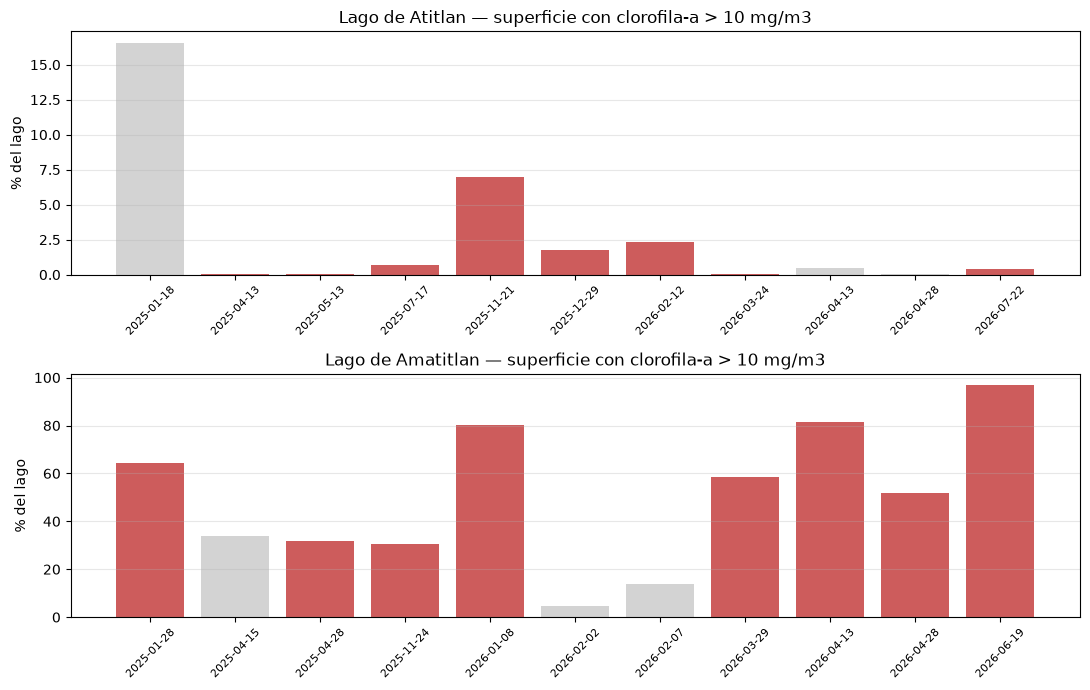

     lago      fecha  pct_floracion  cobertura  area_rel  confiable
Amatitlan 2025-01-28           64.3      100.0      80.7       True
Amatitlan 2025-04-15           34.0      100.0      35.3      False
Amatitlan 2025-04-28           31.8       99.9      67.5       True
Amatitlan 2025-11-24           30.6       99.8      86.1       True
Amatitlan 2026-01-08           80.1       99.7      90.3       True
Amatitlan 2026-02-02            4.7      100.0       7.1      False
Amatitlan 2026-02-07           13.9      100.0      30.2      False
Amatitlan 2026-03-29           58.4      100.0      66.3       True
Amatitlan 2026-04-13           81.4      100.0     100.0       True
Amatitlan 2026-04-28           51.9       98.7      97.2       True
Amatitlan 2026-06-19           96.7       99.8      96.0       True
  Atitlan 2025-01-18           16.6       23.4      96.0      False
  Atitlan 2025-04-13            0.0      100.0      78.9       True
  Atitlan 2025-05-13            0.0      100.0  

In [33]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))

for ax, lago in zip(axes, ["Atitlan", "Amatitlan"]):
    g = TEMPORAL_OK[TEMPORAL_OK.lago == lago]
    colores = ["indianred" if c else "lightgray" for c in g.confiable]
    ax.bar(g.fecha.dt.strftime("%Y-%m-%d"), g.pct_floracion, color=colores)
    ax.set_title(f"Lago de {lago} — superficie con clorofila-a > {UMBRAL_FLORACION} mg/m3")
    ax.set_ylabel("% del lago")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.grid(alpha=0.3, axis="y")

fig.tight_layout()
fig.savefig(DATOS / "resultados" / "extension_floracion.png", dpi=120)
plt.show()

print(TEMPORAL_OK[["lago", "fecha", "pct_floracion", "cobertura", "area_rel", "confiable"]]
      .round(1).to_string(index=False))


Amatitlán mantiene entre 30% y 97% del lago en floración en todas sus fechas
confiables. Atitlán no pasa del 7%. Las tres escenas descartadas de cada lago se
deben a cobertura parcial del espejo de agua por nubes —en Atitlán 2026-04-13
solo se ve el 16% y en Amatitlán 2026-02-02 apenas el 7%— salvo Atitlán
2025-01-18, descartada porque únicamente el 23% del agua detectada tuvo índice
válido. El descarte de Amatitlán 2026-02-07 coincide con la advertencia del
enunciado sobre su cobertura parcial.

### 8.2 Zonas persistentes de acumulación

Para cada píxel contamos en qué fracción de las fechas confiables superó el
umbral. Un valor de 1.0 significa que ese punto estuvo en floración **en todas**
las fechas observadas. Solo se evalúan los píxeles con dato válido en al menos
la mitad de las fechas.

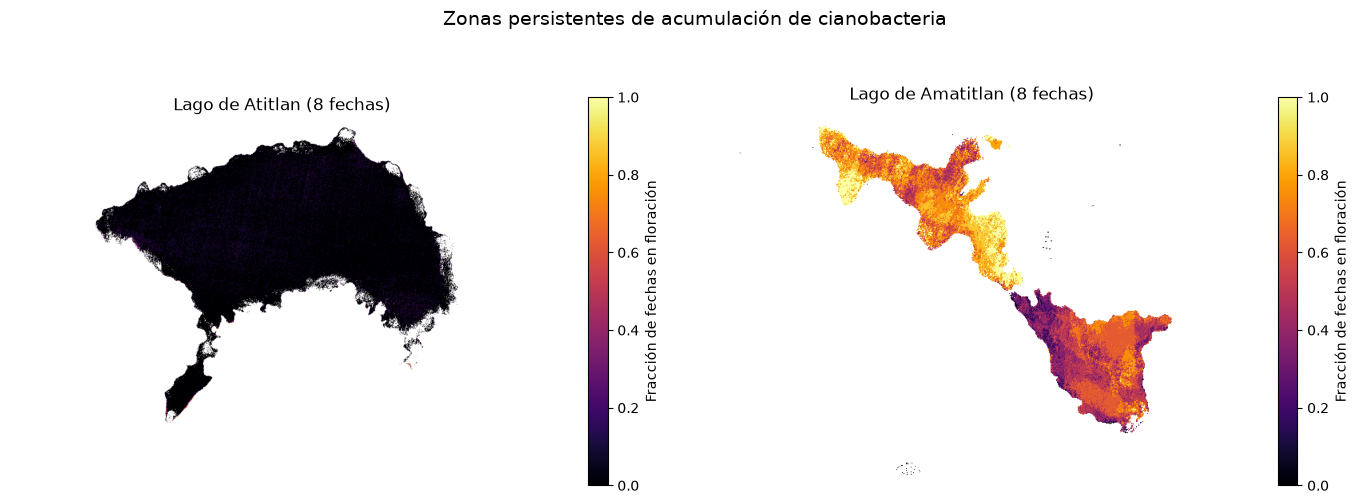

Atitlan: nunca en floración  90.4% | en más de la mitad de las fechas   0.1% | siempre  0.0% (0.01 km2)
Amatitlan: nunca en floración   0.4% | en más de la mitad de las fechas  69.2% | siempre  8.9% (1.21 km2)


In [34]:
def mapa_persistencia(lago):
    """Fracción de fechas confiables en que cada píxel superó el umbral."""
    fechas = TEMPORAL_OK.loc[
        (TEMPORAL_OK.lago == lago) & TEMPORAL_OK.confiable, "fecha"
    ].dt.strftime("%Y-%m-%d").tolist()

    sobre = valido = None
    for fecha in fechas:
        chla = indices_saneados(lago, fecha)["chla"]
        hay = np.isfinite(chla)
        sobre = (np.nan_to_num(chla) > UMBRAL_FLORACION).astype("int16") if sobre is None \
            else sobre + (np.nan_to_num(chla) > UMBRAL_FLORACION)
        valido = hay.astype("int16") if valido is None else valido + hay

    suficiente = valido >= len(fechas) // 2
    return np.where(suficiente, sobre / np.maximum(valido, 1), np.nan), len(fechas)


PERSISTENCIA = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, lago in zip(axes, ["Atitlan", "Amatitlan"]):
    frec, n = mapa_persistencia(lago)
    PERSISTENCIA[lago] = frec
    im = ax.imshow(frec, cmap="inferno", vmin=0, vmax=1)
    ax.set_title(f"Lago de {lago} ({n} fechas)")
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.8, label="Fracción de fechas en floración")

fig.suptitle("Zonas persistentes de acumulación de cianobacteria", fontsize=14)
fig.tight_layout()
fig.savefig(DATOS / "resultados" / "persistencia.png", dpi=120)
plt.show()

for lago, frec in PERSISTENCIA.items():
    f = frec[np.isfinite(frec)]
    print(f"{lago}: nunca en floración {100*(f==0).mean():5.1f}% | "
          f"en más de la mitad de las fechas {100*(f>0.5).mean():5.1f}% | "
          f"siempre {100*(f==1).mean():4.1f}% ({(f==1).sum()*400/1e6:.2f} km2)")

El contraste es casi perfecto. En **Atitlán** el 90.4% del lago no superó el umbral en
ninguna fecha y prácticamente ningún píxel está siempre en floración
(0.01 km²): no hay focos persistentes, solo episodios dispersos.

En **Amatitlán** apenas el 0.4% del lago se libra en todas las fechas, el 69.2%
está en floración en más de la mitad de las observaciones, y **1.21 km² (8.9%
del lago) superan el umbral en el 100% de las fechas**. Ese núcleo persistente
está centrado en coordenadas −90.583, 14.470, con el 94% de su superficie en la mitad oeste
del lago: justo la zona de desembocadura del río Villalobos. La coincidencia
entre el foco persistente y la entrada de aguas residuales es la evidencia más
directa de que la proliferación en Amatitlán es de origen puntual y continuo, no
un fenómeno difuso.

### 8.3 Distribución de valores entre fechas

Tres vistas sobre la misma pregunta: histogramas para ver la forma de la
distribución, boxplots para comparar fecha a fecha, y un mapa de diferencia
entre la fecha más baja y la más alta de cada lago.

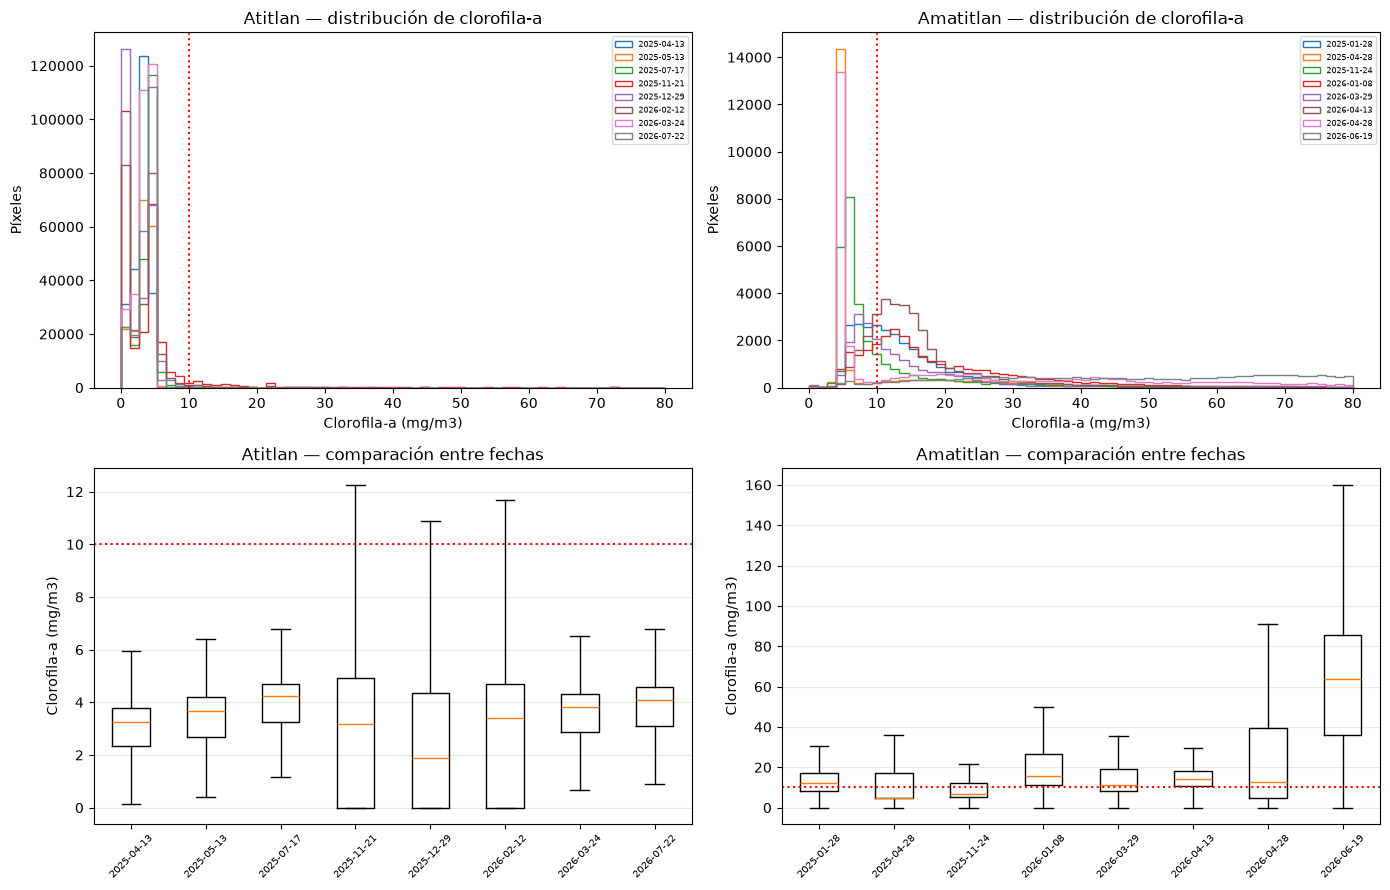

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for col, lago in enumerate(["Atitlan", "Amatitlan"]):
    fechas = TEMPORAL_OK.loc[
        (TEMPORAL_OK.lago == lago) & TEMPORAL_OK.confiable, "fecha"
    ].dt.strftime("%Y-%m-%d").tolist()
    muestras = [indices_saneados(lago, f)["chla"] for f in fechas]
    muestras = [m[np.isfinite(m)] for m in muestras]

    # Histograma superpuesto
    ax = axes[0, col]
    for fecha, m in zip(fechas, muestras):
        ax.hist(m, bins=60, range=(0, 80), histtype="step", label=fecha)
    ax.axvline(UMBRAL_FLORACION, color="red", ls=":")
    ax.set_title(f"{lago} — distribución de clorofila-a")
    ax.set_xlabel("Clorofila-a (mg/m3)")
    ax.set_ylabel("Píxeles")
    ax.legend(fontsize=6)

    # Boxplot por fecha
    ax = axes[1, col]
    ax.boxplot(muestras, tick_labels=fechas, showfliers=False)
    ax.axhline(UMBRAL_FLORACION, color="red", ls=":")
    ax.set_title(f"{lago} — comparación entre fechas")
    ax.set_ylabel("Clorofila-a (mg/m3)")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.grid(alpha=0.3, axis="y")

fig.tight_layout()
fig.savefig(DATOS / "resultados" / "distribuciones.png", dpi=120)
plt.show()

Atitlan: cambio medio +2.1 mg/m3, 49% de los píxeles aumentan
Amatitlan: cambio medio +51.6 mg/m3, 93% de los píxeles aumentan


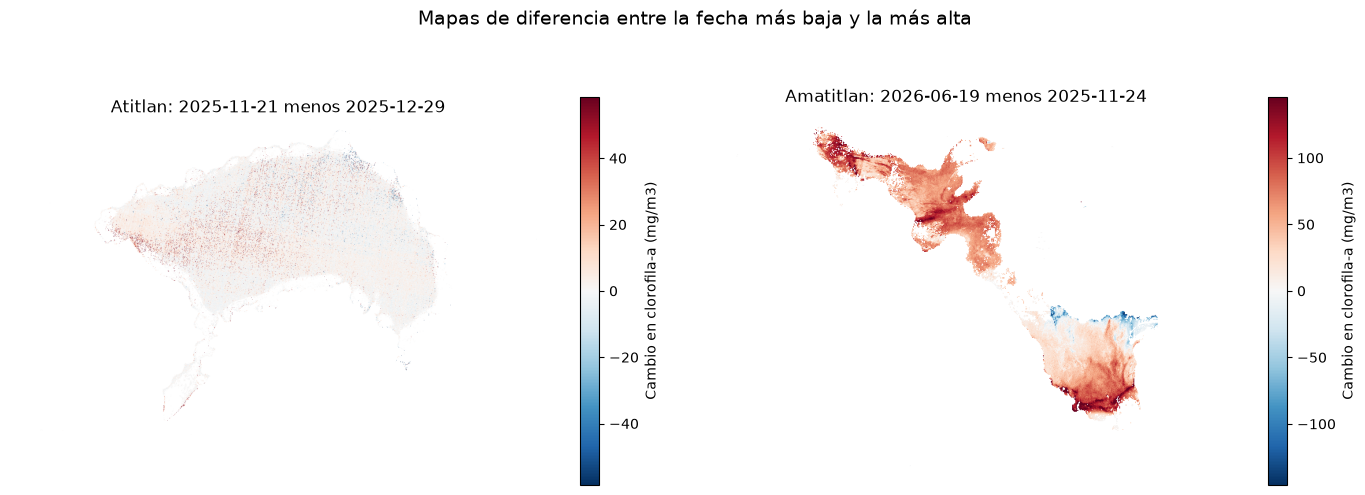

In [36]:
# Mapa de diferencia: fecha de menor y de mayor floración de cada lago
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, lago in zip(axes, ["Atitlan", "Amatitlan"]):
    g = CONFIABLES[CONFIABLES.lago == lago]
    baja = g.loc[g.chla_media.idxmin(), "fecha"].strftime("%Y-%m-%d")
    alta = g.loc[g.chla_media.idxmax(), "fecha"].strftime("%Y-%m-%d")

    diferencia = indices_saneados(lago, alta)["chla"] - indices_saneados(lago, baja)["chla"]
    limite = np.nanpercentile(np.abs(diferencia), 99)
    im = ax.imshow(diferencia, cmap="RdBu_r", vmin=-limite, vmax=limite)
    ax.set_title(f"{lago}: {alta} menos {baja}")
    ax.axis("off")
    fig.colorbar(im, ax=ax, shrink=0.8, label="Cambio en clorofila-a (mg/m3)")

    d = diferencia[np.isfinite(diferencia)]
    print(f"{lago}: cambio medio {d.mean():+.1f} mg/m3, "
          f"{100*(d>0).mean():.0f}% de los píxeles aumentan")

fig.suptitle("Mapas de diferencia entre la fecha más baja y la más alta", fontsize=14)
fig.tight_layout()
fig.savefig(DATOS / "resultados" / "mapas_diferencia.png", dpi=120)
plt.show()

Los histogramas muestran distribuciones de forma distinta. En Atitlán todas las
fechas se concentran en un pico estrecho por debajo de 5 mg/m³, y las curvas de
las distintas fechas casi se superponen: el lago es estable. En Amatitlán las
distribuciones son anchas y se desplazan entre fechas; la del 2026-06-19 se corre
por completo a la derecha del umbral.

Los mapas de diferencia confirman la escala del cambio. En Amatitlán, entre
2025-11-24 y 2026-06-19 la clorofila-a sube en promedio **+51.6 mg/m³** y el
**93% de los píxeles aumentan**: la floración crece en todo el lago a la vez. En
Atitlán el cambio entre su fecha más baja y la más alta es de **+2.1 mg/m³** con
solo el 49% de los píxeles al alza, es decir, tanto sube como baja según la zona:
ruido espacial más que un evento de floración.

### 8.4 Patrón estacional

                              n_fechas  chla_media  extension
lago      temporada                                          
Amatitlan Lluviosa (may-oct)         1   63.470001      96.74
          Seca (nov-abr)             7   17.230000      56.93
Atitlan   Lluviosa (may-oct)         3    3.640000       0.38
          Seca (nov-abr)             5    3.570000       2.24


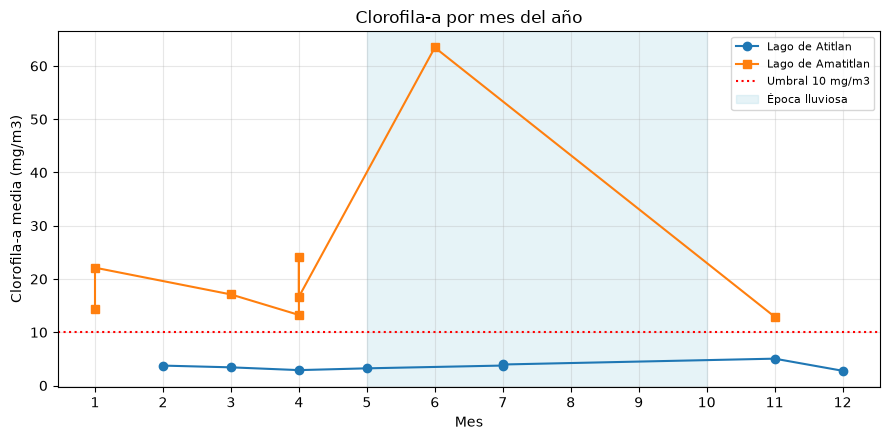

In [37]:
CONFIABLES = CONFIABLES.copy()
CONFIABLES["mes"] = CONFIABLES.fecha.dt.month
CONFIABLES["temporada"] = np.where(
    CONFIABLES.mes.isin([5, 6, 7, 8, 9, 10]), "Lluviosa (may-oct)", "Seca (nov-abr)"
)

estacional = CONFIABLES.groupby(["lago", "temporada"]).agg(
    n_fechas=("chla_media", "size"),
    chla_media=("chla_media", "mean"),
    extension=("pct_floracion", "mean"),
).round(2)
print(estacional.to_string())

fig, ax = plt.subplots(figsize=(9, 4.5))
for lago, marcador in [("Atitlan", "o"), ("Amatitlan", "s")]:
    g = CONFIABLES[CONFIABLES.lago == lago].sort_values("mes")
    ax.plot(g.mes, g.chla_media, marcador, ls="-", label=f"Lago de {lago}")
ax.axhline(UMBRAL_FLORACION, color="red", ls=":", label="Umbral 10 mg/m3")
ax.axvspan(5, 10, color="lightblue", alpha=0.3, label="Época lluviosa")
ax.set_xlabel("Mes")
ax.set_ylabel("Clorofila-a media (mg/m3)")
ax.set_xticks(range(1, 13))
ax.set_title("Clorofila-a por mes del año")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(DATOS / "resultados" / "estacionalidad.png", dpi=120)
plt.show()

**Los datos no permiten confirmar un patrón estacional.** El reparto de fechas
es muy desigual: de las 8 escenas confiables de Amatitlán, 7 caen en época seca
y solo 1 en lluviosa, y en Atitlán la división es 5 contra 3.

Lo que se observa con esa limitación:

- En **Amatitlán** el valor más alto de toda la serie es el único dato de época
  lluviosa (2026-06-19, 63.5 mg/m³, contra 17.2 mg/m³ de promedio en seca). Es
  consistente con la idea de que las lluvias arrastran nutrientes de la cuenca,
  pero **un solo punto no sustenta una conclusión estacional**; podría ser un
  evento aislado.
- En **Atitlán** no hay diferencia: 3.6 mg/m³ en lluviosa contra 3.6 mg/m³ en
  seca. El lago se mantiene estable todo el año.

Para responder esta pregunta correctamente harían falta fechas repartidas de
forma pareja entre ambas temporadas y en varios años.

### 8.5 Interpretación conjunta

Los cuatro análisis apuntan a la misma conclusión, y cada uno aporta una pieza
distinta:

**Los lagos requieren estrategias de monitoreo diferentes.** En Amatitlán la
floración es el estado normal (8 de 8 fechas, 61.9% del lago en promedio), así
que la pregunta útil no es *si* hay floración sino *cuánto* ha empeorado. En
Atitlán la floración es la excepción (0 de 8 fechas), y ahí sí tiene sentido un
sistema de alerta que dispare ante episodios puntuales.

**El origen del problema es distinto en cada lago.** El mapa de persistencia
(8.2) localiza en Amatitlán un núcleo de 1.21 km² que está en floración el 100%
del tiempo, ubicado en la desembocadura del Villalobos. Eso señala una fuente
puntual y continua: mientras no se trate esa descarga, el resto de medidas serán
paliativas. En Atitlán no existe ningún foco persistente, y los valores altos
aparecen en bordes costeros que cambian de una fecha a otra, compatibles con
escorrentía local dispersa.

**La diferencia no es de grado sino de estado.** Los rangos de ambos lagos no se
traslapan (Mann-Whitney p = 0.0002): el peor día de Atitlán sigue siendo más
limpio que el mejor día de Amatitlán. Son dos regímenes distintos, no dos puntos
de una misma escala.

**Atitlán está bien pero no está a salvo.** Su ventaja es física —volumen y
profundidad diluyen la carga—, no una menor presión sobre la cuenca. Los focos
costeros detectados indican que la entrada de nutrientes ya ocurre; lo que falta
es que supere la capacidad de dilución del lago.

**Limitaciones.** El análisis usa 8 fechas confiables por lago sobre 11
disponibles, concentradas en época seca. La clorofila-a proviene de un modelo
óptico (NDCI) calibrado con datos simulados y no de muestreo in situ, así que
los valores absolutos deben leerse como órdenes de magnitud; las comparaciones
relativas entre lagos y entre fechas, que es lo que sostiene estas conclusiones,
son mucho más robustas.

**Configuración funciones base**

In [38]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import rasterio
from pyproj import Transformer

np.seterr(divide="ignore", invalid="ignore")
sns.set_style("whitegrid")

DATOS = Path("data")
BANDAS = ["B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12"]
UMBRAL_FLORACION = 10  # mg/m3 de clorofila-a — mismo umbral usado en la Parte I

In [39]:
def leer_bandas_v2(ruta):
    """Lee un GeoTIFF de la Parte I y devuelve {banda: reflectancia 0-1, con NaN en NoData}."""
    with rasterio.open(ruta) as src:
        datos = src.read().astype("float32")
        nombres = list(src.descriptions)
        sin_dato = src.nodata
        transform = src.transform
        crs = src.crs
    if sin_dato is not None:
        datos[datos == sin_dato] = np.nan
    bandas = dict(zip(nombres if all(nombres) else BANDAS, datos / 10000))
    return bandas, transform, crs


def dif_norm(a, b):
    """Diferencia normalizada, solo donde ambas reflectancias son positivas (idéntico a la Parte I)."""
    ok = (a > 0) & (b > 0)
    return np.where(ok, (a - b) / np.where(ok, a + b, 1), np.nan)


def mascara_agua(b):
    """Detección de agua (script Sentinel Hub / Gartner), igual que en la Parte I."""
    ndvi = dif_norm(b["B08"], b["B04"])
    mndwi = dif_norm(b["B03"], b["B11"])
    ndwi = dif_norm(b["B03"], b["B08"])
    ndwi_hojas = dif_norm(b["B08"], b["B11"])
    aweish = b["B02"] + 2.5 * b["B03"] - 1.5 * (b["B08"] + b["B11"]) - 0.25 * b["B12"]
    aweinsh = 4 * (b["B03"] - b["B11"]) - (0.25 * b["B08"] + 2.75 * b["B11"])
    dbsi = dif_norm(b["B11"], b["B03"]) - ndvi

    agua = (
        (mndwi > 0.42) | (ndwi > 0.4) | (aweinsh > 0.1879)
        | (aweish > 0.1112) | (ndvi < -0.2) | (ndwi_hojas > 1)
    )
    urbano_o_suelo = (aweinsh <= -0.03) | (dbsi > 0)
    return agua & ~urbano_o_suelo

---
# Parte 2. Preparación de los datos para Machine Learning

### 1.1–1.2 Construcción del conjunto de datos por observación geográfica

Cada fila del dataset final es **un píxel de agua válido** de una escena, con sus coordenadas, fecha, lago, bandas espectrales, NDVI, NDWI y el índice continuo de cianobacteria (clorofila-a). Para esto:

1. Reproyectamos los píxeles a coordenadas (los rasters ya vienen en **UTM 15N / EPSG:32615**, igual que pide la sección 6.1 de este laboratorio) y calculamos también lon/lat en EPSG:4326 para visualización.
2. Aplicamos un **submuestreo espacial sistemático** (parámetro `STRIDE`): en vez de usar los ~20 m nativos, conservamos 1 de cada `STRIDE` píxeles por eje. Justificación en 1.6.

In [40]:
def coords_pixeles(transform, crs, alto, ancho, stride=1):
    """Coordenadas del centro de cada píxel conservado tras el submuestreo.

    Usa los índices ORIGINALES de fila/columna (0, stride, 2*stride, ...) contra el
    transform original del raster, para que las coordenadas sean exactas incluso
    cuando stride > 1 (evita el error de desplazar el centro del píxel).
    """
    filas_idx = np.arange(0, alto, stride)
    cols_idx = np.arange(0, ancho, stride)
    FILAS, COLS = np.meshgrid(filas_idx, cols_idx, indexing="ij")
    xs, ys = rasterio.transform.xy(transform, FILAS, COLS, offset="center")
    x = np.array(xs).reshape(FILAS.shape)
    y = np.array(ys).reshape(FILAS.shape)

    transformer = Transformer.from_crs(crs, "EPSG:4326", always_xy=True)
    lon, lat = transformer.transform(x, y)
    return x, y, lon, lat

In [41]:
def construir_dataset_pixel(ruta, lago, fecha, stride=1):

    b, transform, crs = leer_bandas_v2(ruta)
    alto, ancho = b["B02"].shape

    if stride > 1:
        b = {k: v[::stride, ::stride] for k, v in b.items()}

    agua = mascara_agua(b)
    ndci = dif_norm(b["B05"], b["B04"])
    chla = np.clip(826.57 * ndci**3 - 176.43 * ndci**2 + 19 * ndci + 4.071, 0, 500)
    fai = b["B07"] - b["B04"] - (b["B8A"] - b["B04"]) * (783 - 665) / (865 - 665)
    ndvi = dif_norm(b["B08"], b["B04"])
    ndwi = dif_norm(b["B03"], b["B08"])

    reflectancia_valida = np.ones(agua.shape, dtype=bool)
    for banda in b.values():
        reflectancia_valida &= np.isfinite(banda) & (banda >= 0) & (banda <= 1)

    sin_vegetacion = fai <= 0.08
    valido = (
        agua & sin_vegetacion & reflectancia_valida
        & np.isfinite(chla) & np.isfinite(ndvi) & np.isfinite(ndwi)
    )

    x, y, lon, lat = coords_pixeles(transform, crs, alto, ancho, stride=stride)

    diagnostico = {
        "lago": lago, "fecha": fecha,
        "pixeles_totales": int(agua.size),
        "pixeles_agua": int(agua.sum()),
        "pixeles_validos": int(valido.sum()),
        "descartados_veg_flotante": int((agua & ~sin_vegetacion).sum()),
        "descartados_reflectancia": int((agua & sin_vegetacion & ~reflectancia_valida).sum()),
    }

    filas = {
        "lago": lago, "fecha": fecha,
        "lon": lon[valido], "lat": lat[valido], "x": x[valido], "y": y[valido],
        "ndvi": ndvi[valido], "ndwi": ndwi[valido],
        "ndci": ndci[valido], "chla": chla[valido],
    }
    for nombre, banda in b.items():
        filas[nombre] = banda[valido]

    return pd.DataFrame(filas), diagnostico

### 1.3 Selección de escenas confiables y limpieza

Además de la limpieza a nivel de píxel (arriba), reutilizamos la validación **a nivel de escena** que ya se hizo en la Parte I (`serie_temporal_saneada.csv`, columna `confiable`): una escena se marcó confiable si su cobertura de píxeles válidos era ≥80% y su área de agua detectada era ≥50% del máximo histórico del lago (para excluir fechas con nubosidad alta o cobertura parcial, como `Amatitlan 2026-02-07` con ~57% de cobertura). Solo usamos escenas confiables para construir el dataset de ML: así evitamos que una escena parcialmente nublada infle artificialmente el número de píxeles de una fecha frente a otra.

In [42]:
TEMPORAL_OK = pd.read_csv(DATOS / "resultados" / "serie_temporal_saneada.csv", parse_dates=["fecha"])
TEMPORAL_OK["fecha"] = TEMPORAL_OK["fecha"].dt.strftime("%Y-%m-%d")

ESCENAS_CONFIABLES = TEMPORAL_OK.loc[TEMPORAL_OK.confiable, ["lago", "fecha"]].reset_index(drop=True)
print(f"Escenas confiables: {len(ESCENAS_CONFIABLES)} de {len(TEMPORAL_OK)} totales")
ESCENAS_CONFIABLES.groupby("lago").size()

Escenas confiables: 16 de 22 totales


lago
Amatitlan    8
Atitlan      8
dtype: int64

In [43]:
STRIDE = 3  # conserva 1 de cada 3 pixeles por eje -> separacion real de 60 m (ver 1.6)

partes, diagnosticos = [], []
for fila in ESCENAS_CONFIABLES.itertuples():
    ruta = DATOS / "raw" / f"{fila.lago}_{fila.fecha}.tif"
    if not ruta.exists():
        print(f"AVISO: no se encontro {ruta.name}; se omite (revisa data/raw/ de la Parte I)")
        continue
    df_escena, diag = construir_dataset_pixel(ruta, fila.lago, fila.fecha, stride=STRIDE)
    partes.append(df_escena)
    diagnosticos.append(diag)
    print(f"{fila.lago:10s} {fila.fecha}: {diag['pixeles_validos']:6d} observaciones validas "
          f"de {diag['pixeles_agua']:6d} pixeles de agua")

if partes:
    DATASET_ML = pd.concat(partes, ignore_index=True)
    DATASET_ML["fecha"] = pd.to_datetime(DATASET_ML["fecha"])
    DIAGNOSTICO = pd.DataFrame(diagnosticos)
else:
    DATASET_ML = pd.DataFrame()
    DIAGNOSTICO = pd.DataFrame()
    print("\nNo se genero ningun dato: verifica que data/raw/ contenga los .tif de la Parte I.")

DATASET_ML.shape

Amatitlan  2025-01-28:   2912 observaciones validas de   3179 pixeles de agua
Amatitlan  2025-04-28:   2578 observaciones validas de   2582 pixeles de agua
Amatitlan  2025-11-24:   3170 observaciones validas de   3372 pixeles de agua
Amatitlan  2026-01-08:   3447 observaciones validas de   3475 pixeles de agua
Amatitlan  2026-03-29:   2545 observaciones validas de   2551 pixeles de agua
Amatitlan  2026-04-13:   3832 observaciones validas de   3838 pixeles de agua
Amatitlan  2026-04-28:   3668 observaciones validas de   3728 pixeles de agua
Amatitlan  2026-06-19:   3610 observaciones validas de   3798 pixeles de agua
Atitlan    2025-04-13:  26037 observaciones validas de  26040 pixeles de agua
Atitlan    2025-05-13:  19296 observaciones validas de  19320 pixeles de agua
Atitlan    2025-07-17:  23334 observaciones validas de  24001 pixeles de agua
Atitlan    2025-11-21:  23504 observaciones validas de  32736 pixeles de agua
Atitlan    2025-12-29:  29059 observaciones validas de  30922 pi

(228886, 19)

In [44]:
DIAGNOSTICO["pct_valido_de_agua"] = (100 * DIAGNOSTICO.pixeles_validos / DIAGNOSTICO.pixeles_agua).round(1)
DIAGNOSTICO

,lago,fecha,pixeles_totales,pixeles_agua,pixeles_validos,descartados_veg_flotante,descartados_reflectancia,pct_valido_de_agua
0,Amatitlan,2025-01-28,34731,3179,2912,0,267,91.6
1,Amatitlan,2025-04-28,34731,2582,2578,4,0,99.8
2,Amatitlan,2025-11-24,34731,3372,3170,10,191,94.0
3,Amatitlan,2026-01-08,34731,3475,3447,14,14,99.2
4,Amatitlan,2026-03-29,34731,2551,2545,1,5,99.8
5,Amatitlan,2026-04-13,34731,3838,3832,0,5,99.8
6,Amatitlan,2026-04-28,34731,3728,3668,60,0,98.4
7,Amatitlan,2026-06-19,34731,3798,3610,11,176,95.1
8,Atitlan,2025-04-13,134320,26040,26037,0,3,100.0
9,Atitlan,2025-05-13,134320,19320,19296,0,23,99.9


### 1.4 Resumen del conjunto de datos

In [45]:
print("=== Resumen general ===")
print(f"Observaciones totales : {len(DATASET_ML):,}")
print(f"Resolucion efectiva   : {STRIDE * 20} m (20 m nativos x STRIDE={STRIDE})")
print()
print("Observaciones por lago:")
display(DATASET_ML.groupby("lago").size().rename("n_observaciones"))
print()
print("Observaciones por lago y fecha:")
display(DATASET_ML.groupby(["lago", "fecha"]).size().rename("n_observaciones"))

=== Resumen general ===
Observaciones totales : 228,886
Resolucion efectiva   : 60 m (20 m nativos x STRIDE=3)

Observaciones por lago:


lago
Amatitlan     25762
Atitlan      203124
Name: n_observaciones, dtype: int64


Observaciones por lago y fecha:


lago       fecha     
Amatitlan  2025-01-28     2912
           2025-04-28     2578
           2025-11-24     3170
           2026-01-08     3447
           2026-03-29     2545
           2026-04-13     3832
           2026-04-28     3668
           2026-06-19     3610
Atitlan    2025-04-13    26037
           2025-05-13    19296
           2025-07-17    23334
           2025-11-21    23504
           2025-12-29    29059
           2026-02-12    24901
           2026-03-24    32922
           2026-07-22    24071
Name: n_observaciones, dtype: int64

In [46]:
resumen_vars = pd.DataFrame({
    "tipo": DATASET_ML.dtypes.astype(str),
    "pct_faltante": DATASET_ML.isna().mean().mul(100).round(2),
    "n_unicos": DATASET_ML.nunique(),
})
resumen_vars

,tipo,pct_faltante,n_unicos
lago,object,0.0,2
fecha,datetime64[ns],0.0,16
lon,float64,0.0,38015
lat,float64,0.0,38015
x,float64,0.0,526
y,float64,0.0,417
ndvi,float32,0.0,24226
ndwi,float32,0.0,29517
ndci,float32,0.0,26895
chla,float32,0.0,24567


Por diseño, el dataset final **no tiene valores faltantes** (0% en todas las columnas): las filas con NoData, nubes, vegetación flotante o reflectancias no físicas ya se descartaron durante la construcción (Ejercicio 1.3), en vez de dejarlas como NaN para imputar después. La tabla `DIAGNOSTICO` de la sección 1.3 documenta cuántas observaciones se perdieron por cada motivo, en caso de que se quiera reportar ese detalle.

### 1.5 Análisis exploratorio

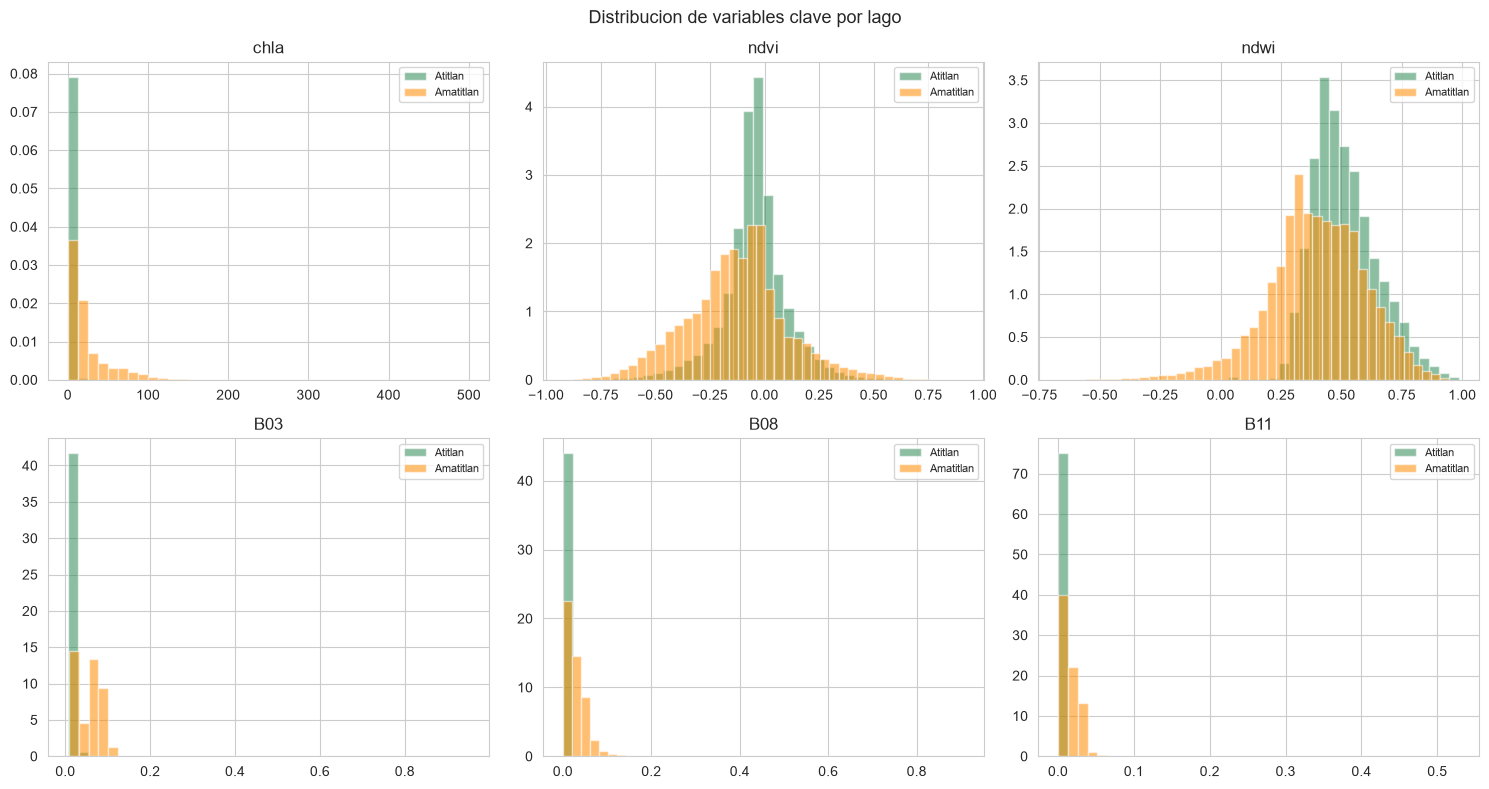

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
variables_eda = ["chla", "ndvi", "ndwi", "B03", "B08", "B11"]

for ax, var in zip(axes.ravel(), variables_eda):
    for lago, color in zip(["Atitlan", "Amatitlan"], ["seagreen", "darkorange"]):
        datos = DATASET_ML.loc[DATASET_ML.lago == lago, var]
        ax.hist(datos, bins=40, alpha=0.55, label=lago, color=color, density=True)
    ax.set_title(var)
    ax.legend(fontsize=8)

fig.suptitle("Distribucion de variables clave por lago", fontsize=13)
fig.tight_layout()
plt.show()

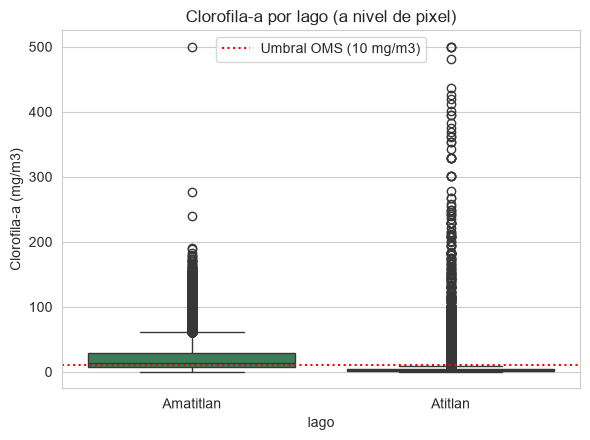

              count   mean    std  min   25%    50%    75%    max
lago                                                             
Amatitlan   25762.0  24.09  26.18  0.0  7.05  13.73  28.62  500.0
Atitlan    203124.0   3.50   7.15  0.0  1.78   3.65   4.44  500.0


In [48]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=DATASET_ML, x="lago", y="chla", hue="lago", ax=ax,
            palette=["seagreen", "darkorange"], legend=False)
ax.axhline(UMBRAL_FLORACION, color="red", ls=":", label=f"Umbral OMS ({UMBRAL_FLORACION} mg/m3)")
ax.set_title("Clorofila-a por lago (a nivel de pixel)")
ax.set_ylabel("Clorofila-a (mg/m3)")
ax.legend()
fig.tight_layout()
plt.show()

print(DATASET_ML.groupby("lago")["chla"].describe().round(2))

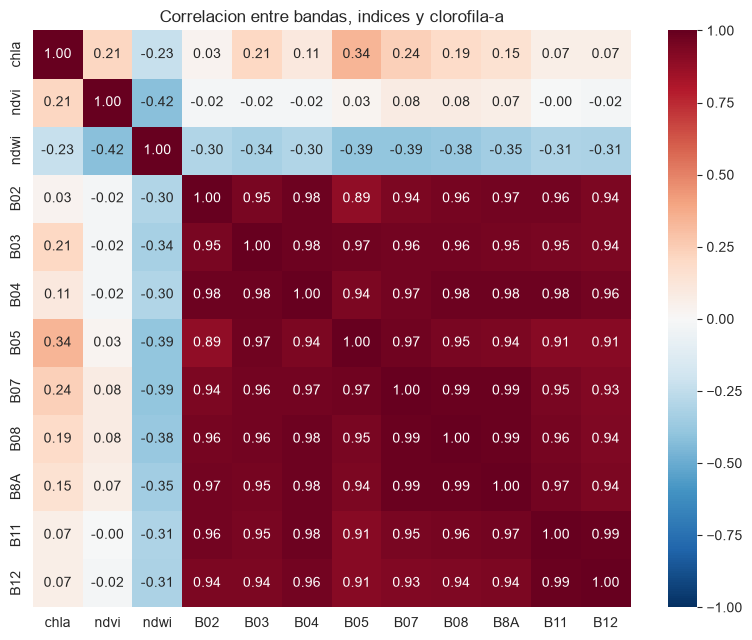

In [49]:
cols_corr = ["chla", "ndvi", "ndwi", "B02", "B03", "B04", "B05", "B07", "B08", "B8A", "B11", "B12"]
corr = DATASET_ML[cols_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlacion entre bandas, indices y clorofila-a")
fig.tight_layout()
plt.show()

**Lectura del heatmap:** presta especial atención a la fila/columna de `chla`. Las bandas `B04` y `B05` deberían mostrar la correlación más fuerte y estructurada con `chla` (porque son las que la definen matemáticamente vía NDCI) 

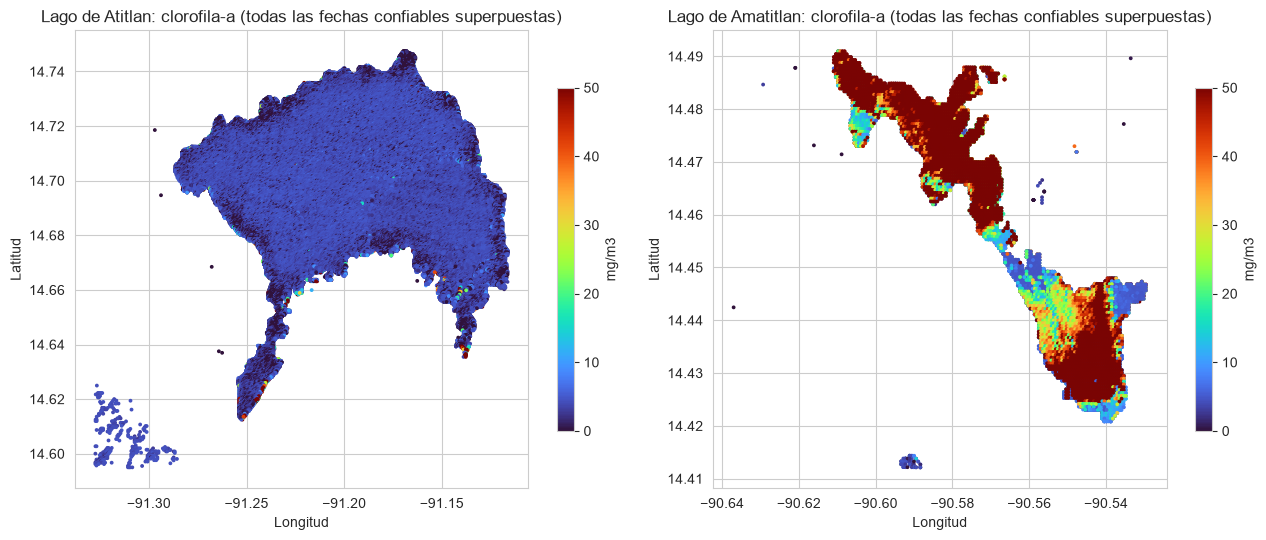

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, lago in zip(axes, ["Atitlan", "Amatitlan"]):
    g = DATASET_ML[DATASET_ML.lago == lago]
    sc = ax.scatter(g.lon, g.lat, c=g.chla, cmap="turbo", vmin=0, vmax=50, s=3)
    ax.set_title(f"Lago de {lago}: clorofila-a (todas las fechas confiables superpuestas)")
    ax.set_xlabel("Longitud")
    ax.set_ylabel("Latitud")
    fig.colorbar(sc, ax=ax, shrink=0.75, label="mg/m3")
fig.tight_layout()
plt.show()

### 1.6 Decisiones tomadas durante la preparación y limpieza

- **Unidad de observación:** un píxel de agua válido en una fecha dada (no un promedio por
  lago/fecha como en la Parte I). Esto es lo que pide el enunciado ("cada observación... asociada
  a una posición geográfica").
- **Filtro de escenas confiables:** se reutilizó la columna `confiable` de la Parte I
  (cobertura ≥80% y área relativa ≥50%) para excluir por completo las 6 escenas con nubosidad
  alta o cobertura parcial, en vez de intentar limpiarlas píxel por píxel. Esto evita que una
  fecha nublada quede sub-representada de forma sesgada (solo se verían los pocos píxeles que
  sí se pudieron observar, no una muestra representativa del lago ese día).
- **Máscara de agua espectral en vez de un polígono fijo:** los `.geojson` de `data/geojson/`
  son solo el rectángulo usado para *descargar* cada escena, no el contorno real del lago. Usar
  la máscara espectral (`mascara_agua`) es más preciso porque el espejo de agua cambia
  ligeramente entre fechas (nivel del lago, orilla) y porque excluye zonas urbanas/suelo que
  caen dentro del rectángulo de descarga pero no son agua.
- **Exclusión de vegetación flotante (`fai > 0.08`)** y de **reflectancias no físicas**
  (fuera de `[0, 1]`, típicamente por artefactos de la corrección atmosférica en los bordes
  de nubes o sombras): mismo criterio que la Parte I, para mantener consistencia con
  `UMBRAL_FLORACION`.
- **Submuestreo espacial sistemático (`STRIDE = 3`, separación real de 60 m):** a 20 m de
  resolución nativa, píxeles vecinos están fuertemente autocorrelacionados espacialmente
  (casi no aportan información independiente) y el dataset completo puede superar varios
  millones de filas, lo cual es difícil de manejar y **exagera artificialmente el tamaño
  muestral** para las pruebas estadísticas de las secciones 5–7. Someter a 1 de cada 3 píxeles
  por eje reduce el dataset ~9x conservando cobertura espacial completa del lago. El valor de
  `STRIDE` es un parámetro ajustable al inicio de la sección 1.3.
- **Sin imputación de datos faltantes:** se optó por descartar píxeles inválidos en vez de
  imputarlos, porque un píxel de nube o de tierra no tiene un valor "verdadero" de clorofila-a
  que tenga sentido inventar.


---
## 2. Construcción de la variable respuesta

### 2.1 Variable binaria

In [51]:
DATASET_ML["cianobacteria_alta"] = (DATASET_ML["chla"] > UMBRAL_FLORACION).astype(int)

print("0 = ausencia/baja presencia   1 = alta presencia\n")
DATASET_ML["cianobacteria_alta"].value_counts().rename("n_observaciones")

0 = ausencia/baja presencia   1 = alta presencia



cianobacteria_alta
0    209583
1     19303
Name: n_observaciones, dtype: int64

### 2.2 Justificación del punto de corte

Para identificar una posible floración se estableció un umbral de **10 µg/L de clorofila-a**, valor equivalente a **10 mg/m³** y aproximadamente a **20 000 células/mL de cianobacterias**. Se mantuvo el mismo valor de `UMBRAL_FLORACION` utilizado en la Parte I, con el objetivo de conservar un criterio uniforme durante todo el análisis.

La elección de este límite se basa en recomendaciones internacionales y no en un valor seleccionado arbitrariamente. El umbral se relaciona con el **primer nivel de alerta ("Alert Level 1")** utilizado como referencia en los sistemas de vigilancia de cianobacterias en aguas recreativas descritos por la Organización Mundial de la Salud (Chorus & Bartram, 1999; WHO, 2003).

En términos generales, concentraciones inferiores a este nivel representan una situación de vigilancia habitual, donde el riesgo de efectos adversos para la salud es relativamente bajo. Cuando se supera el umbral, aumenta la preocupación por la presencia de cianobacterias y se vuelve recomendable intensificar el monitoreo y considerar medidas preventivas, como informar a las autoridades o advertir a los usuarios del cuerpo de agua.

Por esta razón, en la clasificación utilizada en este trabajo:

- **1** indica que el píxel alcanzó o superó el umbral definido y, por lo tanto, representa una condición de alerta.
- **0** indica que el píxel permanece por debajo del umbral y se considera dentro de una condición normal de vigilancia.

**Referencias:**

- Chorus, I. & Bartram, J. (eds.) (1999). *Toxic Cyanobacteria in Water: A Guide to their Public Health Consequences, Monitoring and Management*. WHO / E&FN Spon.
- World Health Organization (2003). *Guidelines for Safe Recreational Water Environments, Volume 1: Coastal and Fresh Waters*. Chapter 8.

### 2.3 Distribución de la variable respuesta

In [52]:
print("Global:")
display(DATASET_ML["cianobacteria_alta"].value_counts(normalize=True).mul(100).round(1).rename("% del total"))

print("\nPor lago:")
display(DATASET_ML.groupby("lago")["cianobacteria_alta"].value_counts(normalize=True).mul(100).round(1).unstack())

print("\nPor fecha:")
por_fecha = DATASET_ML.groupby(["lago", "fecha"])["cianobacteria_alta"].mean().mul(100).round(1)
display(por_fecha.rename("% alta presencia"))

Global:


cianobacteria_alta
0    91.6
1     8.4
Name: % del total, dtype: float64


Por lago:


cianobacteria_alta,0,1
lago,,
Amatitlan,36.1,63.9
Atitlan,98.6,1.4



Por fecha:


lago       fecha     
Amatitlan  2025-01-28    62.9
           2025-04-28    32.1
           2025-11-24    31.2
           2026-01-08    80.5
           2026-03-29    59.4
           2026-04-13    81.0
           2026-04-28    52.0
           2026-06-19    97.0
Atitlan    2025-04-13     0.0
           2025-05-13     0.0
           2025-07-17     0.7
           2025-11-21     6.7
           2025-12-29     1.6
           2026-02-12     2.0
           2026-03-24     0.1
           2026-07-22     0.4
Name: % alta presencia, dtype: float64

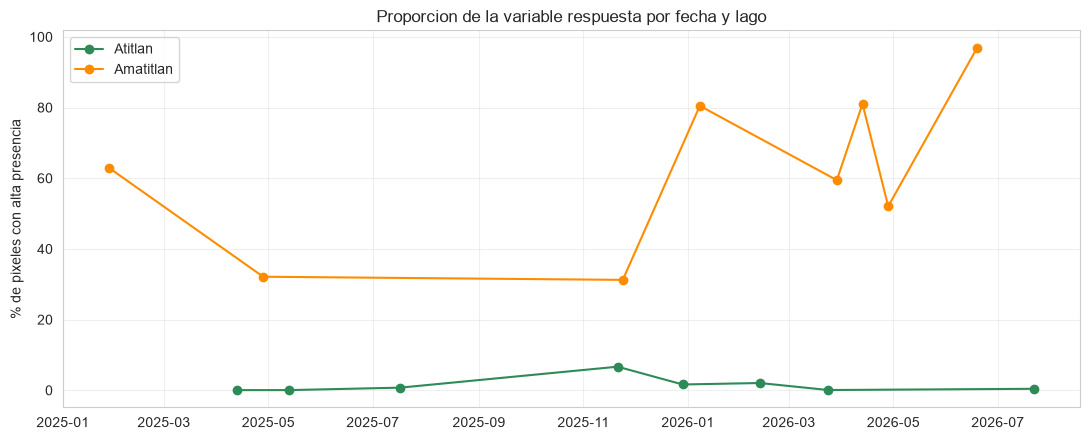

In [53]:
fig, ax = plt.subplots(figsize=(11, 4.5))
tabla = DATASET_ML.groupby(["lago", "fecha"])["cianobacteria_alta"].mean().mul(100).reset_index()
for lago, color in zip(["Atitlan", "Amatitlan"], ["seagreen", "darkorange"]):
    g = tabla[tabla.lago == lago]
    ax.plot(g.fecha, g.cianobacteria_alta, marker="o", label=lago, color=color)
ax.set_ylabel("% de pixeles con alta presencia")
ax.set_title("Proporcion de la variable respuesta por fecha y lago")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

### 2.4 Desbalance de clases

Revisa la proporción global impresa en 2.3 antes de leer esto (varía si cambias `STRIDE` o el
período). En general se espera una clase minoritaria (`1 = alta presencia`), especialmente en
Atitlán, que tiene concentraciones de clorofila-a mucho más bajas y estables que Amatitlán
(ver comparación de la Parte I).

**Consecuencias de entrenar con clases desbalanceadas:**
- **Accuracy es engañoso:** un modelo que siempre prediga 0 puede tener accuracy alta solo
  por la proporción de clases, sin detectar ningún caso real de floración.
- **Los modelos tienden a favorecer la clase mayoritaria** durante el entrenamiento (minimizan
  el error total, no el error por clase), lo que baja específicamente el *recall* de la clase 1
  — justo la que más importa detectar desde el punto de vista de salud pública/ambiental.
- **Estrategias a considerar en el Ejercicio 4:** `class_weight="balanced"` en
  Regresión Logística/Random Forest, `scale_pos_weight` en XGBoost, muestreo estratificado en
  la división train/test, y evaluar con F1-score/ROC-AUC/Recall en vez de solo accuracy
  (esto se retoma formalmente en el Ejercicio 5).


### 2.5 Variables que no pueden usarse como predictoras (fuga de datos)

La variable respuesta se construye así: `cianobacteria_alta = 1` si `chla > 10`, y

$$\text{chla} = 826.57 \cdot \text{ndci}^3 - 176.43 \cdot \text{ndci}^2 + 19 \cdot \text{ndci} + 4.071,
\qquad \text{ndci} = \frac{B05 - B04}{B05 + B04}$$

Es decir, `chla` (y por lo tanto la variable respuesta) es una **función determinística de
solo dos columnas: `B04` y `B05`**. Deben excluirse de las predictoras:

| Variable | Por qué se excluye |
|---|---|
| `chla` | Es literalmente la variable con la que se construyó la respuesta (umbral directo). |
| `ndci` | Determina `chla` de forma exacta (relación cúbica 1 a 1); usarla sería casi tan grave como usar `chla`. |
| `B04` | Junto con `B05`, determina `ndci` (y por lo tanto `chla`) por completo. |
| `B05` | Idem — sin `B04` y `B05` es imposible reconstruir `ndci`. |

**Nota sobre NDVI:** `NDVI = (B08 − B04) / (B08 + B04)` también usa `B04`, pero con una
banda distinta a `B05` — no permite reconstruir `ndci`/`chla` de forma exacta. El enunciado
pide explícitamente incluir NDVI como variable del dataset, así que se conserva como
predictora en el Ejercicio 3, dejando esta salvedad documentada.

Se puede comprobar empíricamente que `chla` es (casi) una función exacta de `B04`/`B05`:


In [54]:
r_ndci_chla = DATASET_ML[["ndci", "chla"]].corr().iloc[0, 1]
print(f"Correlacion ndci vs chla: {r_ndci_chla:.4f}  (relacion determinística por construccion)")

VARIABLES_EXCLUIDAS_FUGA = ["chla", "ndci", "B04", "B05"]
print("Variables excluidas de las predictoras por fuga de datos:", VARIABLES_EXCLUIDAS_FUGA)

Correlacion ndci vs chla: 0.6843  (relacion determinística por construccion)
Variables excluidas de las predictoras por fuga de datos: ['chla', 'ndci', 'B04', 'B05']


---
## 3. Selección y construcción de variables predictoras

### 3.3 Ingeniería de características

Antes de fijar el conjunto final (3.1), construimos dos variables adicionales:

- **`turbidez_proxy = B03 / B02`** (verde/azul): proxy simple de turbidez/sedimento en aguas interiores — a mayor turbidez, mayor reflectancia en verde relativa al azul. No usa `B04` ni `B05`, así que no tiene el problema de fuga del Ejercicio 2.5.
- **`mes`** y **`dia_juliano`** (a partir de `fecha`): capturan estacionalidad (época seca vs. lluviosa en Guatemala), relevante porque la escorrentía de nutrientes y la estratificación térmica —factores que favorecen floraciones— varían con la temporada.

In [55]:
DATASET_ML["turbidez_proxy"] = DATASET_ML["B03"] / DATASET_ML["B02"]
DATASET_ML["mes"] = DATASET_ML["fecha"].dt.month
DATASET_ML["dia_juliano"] = DATASET_ML["fecha"].dt.dayofyear

DATASET_ML[["turbidez_proxy", "mes", "dia_juliano"]].describe().round(2)

,turbidez_proxy,mes,dia_juliano
count,228886.00,228886.00,228886.00
mean,0.85,6.11,174.16
std,0.32,3.50,109.84
min,0.46,1.00,8.00
25%,0.69,3.00,83.00
50%,0.75,5.00,133.00
75%,0.81,7.00,203.00
max,4.54,12.00,363.00


### 3.1 Conjunto final de variables predictoras

```
VARIABLES_PREDICTORAS = [
    "B02", "B03", "B07", "B08", "B8A", "B11", "B12",   # bandas espectrales (sin B04/B05)
    "ndvi", "ndwi",                                     # indices espectrales
    "turbidez_proxy",                                   # feature de ingenieria
    "lon", "lat",                                       # posicion geografica
    "mes", "dia_juliano",                                # temporales / estacionalidad
]
```

`lago` **no** se incluye en este conjunto base: se usará como *variable de agrupación* (para
`GroupKFold`/bloques espaciales en el Ejercicio 6 y para separar entrenamiento/prueba entre
lagos en el Ejercicio 7), no como predictora, porque en el experimento de generalización entre
lagos (7.1–7.2) un modelo entrenado solo con Atitlán nunca vería la categoría "Amatitlán" —
incluirla ahí sería tramposo. Si en el Ejercicio 4 se entrena un modelo único con ambos lagos
mezclados, se puede evaluar aparte una versión con `lago` como dummy adicional y comparar.


In [56]:
VARIABLES_PREDICTORAS = [
    "B02", "B03", "B07", "B08", "B8A", "B11", "B12",
    "ndvi", "ndwi",
    "turbidez_proxy",
    "lon", "lat",
    "mes", "dia_juliano",
]

X = DATASET_ML[VARIABLES_PREDICTORAS].copy()
y = DATASET_ML["cianobacteria_alta"].copy()

print("X:", X.shape, " y:", y.shape)
X.head()

X: (228886, 14)  y: (228886,)


,B02,B03,B07,B08,B8A,B11,B12,ndvi,ndwi,turbidez_proxy,lon,lat,mes,dia_juliano
0,0.8783,0.8475,0.5971,0.7409,0.6008,0.4161,0.3125,-0.049519,0.067112,0.964932,-90.533574,14.489626,1,28
1,0.0139,0.0187,0.0102,0.0079,0.0075,0.0090,0.0084,-0.261682,0.406015,1.345324,-90.608686,14.489319,1,28
2,0.0111,0.0175,0.0112,0.0079,0.0069,0.0091,0.0089,-0.247619,0.377953,1.576577,-90.608130,14.489313,1,28
3,0.0162,0.0203,0.0108,0.0089,0.0080,0.0094,0.0093,-0.245763,0.390411,1.253086,-90.609248,14.488783,1,28
4,0.0171,0.0193,0.0108,0.0100,0.0083,0.0117,0.0109,-0.203187,0.317406,1.128655,-90.608135,14.488771,1,28


### 3.2 Descripción de cada variable predictora

| Variable | Qué representa | Por qué contribuye a detectar cianobacteria | Tipo |
|---|---|---|---|
| `B02` | Reflectancia azul (490 nm) | Sensible a materia en suspensión y profundidad óptica del agua | Banda espectral |
| `B03` | Reflectancia verde (560 nm) | La clorofila absorbe azul/rojo y refleja verde; sube con biomasa algal en general | Banda espectral |
| `B07` | Red edge 2 (783 nm) | Usada en el índice de vegetación flotante (FAI); sensible a pigmentos fotosintéticos | Banda espectral |
| `B08` | NIR (842 nm) | El agua absorbe casi todo el NIR salvo cuando hay biomasa/materia flotante en superficie | Banda espectral |
| `B8A` | NIR estrecho (865 nm) | Similar a B08, más sensible a diferenciar vegetación de agua pura | Banda espectral |
| `B11` | SWIR1 (1610 nm) | Muy sensible a contenido de agua/humedad; ayuda a distinguir agua de tierra/nubes | Banda espectral |
| `B12` | SWIR2 (2190 nm) | Similar a B11, refuerza la distinción agua/no-agua y detecta turbidez alta | Banda espectral |
| `ndvi` | Índice de vegetación (B08,B04) | Valores menos negativos sobre agua sugieren biomasa fotosintética en superficie | Índice espectral |
| `ndwi` | Índice de agua (B03,B08) | Indica qué tan "puro" es el píxel de agua; el ruido de borde de orilla puede confundirse con biomasa | Índice espectral |
| `turbidez_proxy` | Razón B03/B02 | La turbidez/sedimento favorece condiciones de estancamiento asociadas a floraciones | Ingeniería de características |
| `lon`, `lat` | Posición geográfica | Captura efectos espaciales no explicados por el espectro: bahías poco profundas, cercanía a afluentes/zonas urbanas, orientación al viento | Característica espacial |
| `mes`, `dia_juliano` | Estacionalidad | Temperatura, lluvia y estratificación térmica varían con la época del año en Guatemala | Temporal |

Todas estas variables se calculan **sin usar `B04`, `B05`, `ndci` ni `chla`**, cumpliendo la
restricción del Ejercicio 2.5.


### 3.3 Ingeniería de características

Se construyen las variables adicionales con información espectral y temporal:

- `turbidez_proxy = B03 / B02`: Es la razón de verde/azul. Una respuesta relativamente mayor en
  verde puede asociarse con partículas suspendidas, sedimento o biomasa que alteran el color
  del agua. Es un proxy espectral, no una medición física directa de turbidez y te dice cuanto de verda hay por cada azul existente.
- `nd_nir_swir = (B08 - B11) / (B08 + B11)`: contraste normalizado entre NIR y SWIR.
  Resume condiciones de humedad y respuesta de la superficie en una escala acotada, y puede
  ayudar a separar agua abierta de píxeles mixtos o material superficial.
- `estacion_sin` y `estacion_cos`: codificación cíclica del día del año. A diferencia de
  usar el número de mes de forma lineal, conserva la cercanía entre diciembre y enero y
  permite representar patrones estacionales relacionados con lluvia, temperatura y mezcla
  de la columna de agua.

Ninguna característica nueva utiliza `B04`, `B05`, `ndci` o `chla`, por lo que no introduce
la fuga de datos identificada en 2.5. Las divisiones usan un denominador mínimo para evitar
valores infinitos. La utilidad real de estas variables se comprobará mediante validación;
su justificación ambiental no garantiza por sí sola que mejoren el modelo.


## 4. Construcción de modelos de Machine Learning
### 4.1 Modelos de clasificación 
Regresión Logística, Random Forest y Gradient Boosting 

In [ ]:
import time

from sklearn.base import clone
from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     RandomizedSearchCV, StratifiedKFold)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

RANDOM_STATE = 42
N_AJUSTE = 60_000  # tamano de la submuestra usada solo para buscar hiperparametros

# 4.2 Division 70/30. stratify conserva la proporcion de clases (8.4 % positivos).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y)

print("Entrenamiento:", X_train.shape, "  Prueba:", X_test.shape)
print(f"Positivos   train={y_train.mean():.4f}   test={y_test.mean():.4f}")

# La busqueda de hiperparametros se hace sobre una submuestra estratificada del
# entrenamiento. Con 160 mil filas y 14 variables el orden de las configuraciones
# ya es estable con 60 mil, y el costo baja a poco mas de un tercio. El modelo
# final si se reentrena con el 100 % del entrenamiento.
X_ajuste, _, y_ajuste, _ = train_test_split(
    X_train, y_train, train_size=N_AJUSTE, random_state=RANDOM_STATE, stratify=y_train)

cv_ajuste = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
print("Submuestra de ajuste:", X_ajuste.shape)

In [ ]:
def tubo(modelo, escalar=False):
    """Pipeline comun: imputacion y, para los modelos lineales, escalado."""
    pasos = [("imputacion", SimpleImputer(strategy="median"))]
    if escalar:
        pasos.append(("escalado", StandardScaler()))
    pasos.append(("modelo", modelo))
    return Pipeline(pasos)


# 4.1 Los tres modelos pedidos, con el espacio de busqueda de 4.3.
# class_weight="balanced" compensa el desbalance 8.4 % / 91.6 % en los tres.
CONFIGURACIONES = {
    "Regresion Logistica": dict(
        pipe=tubo(LogisticRegression(class_weight="balanced", max_iter=1000,
                                     random_state=RANDOM_STATE), escalar=True),
        rejilla={"modelo__C": [0.01, 0.1, 1, 10]},
        n_iter=None,  # solo 4 candidatos: se recorre la rejilla completa
    ),
    "Random Forest": dict(
        pipe=tubo(RandomForestClassifier(class_weight="balanced", n_jobs=1,
                                         random_state=RANDOM_STATE)),
        rejilla={"modelo__n_estimators": [200, 300, 400],
                 "modelo__max_depth": [10, 20, None],
                 "modelo__min_samples_leaf": [1, 5, 10],
                 "modelo__max_features": ["sqrt", 0.7]},
        n_iter=12,  # 12 de las 54 combinaciones posibles
    ),
    "Gradient Boosting": dict(
        pipe=tubo(HistGradientBoostingClassifier(class_weight="balanced", max_iter=400,
                                                 early_stopping=True,
                                                 random_state=RANDOM_STATE)),
        rejilla={"modelo__learning_rate": [0.03, 0.05, 0.1],
                 "modelo__max_leaf_nodes": [15, 31, 63],
                 "modelo__min_samples_leaf": [20, 50],
                 "modelo__l2_regularization": [0.0, 0.1, 1.0]},
        n_iter=12,  # 12 de las 54 combinaciones posibles
    ),
}

# Criterio de seleccion: F1 sobre la clase positiva, que equilibra precision y
# recall sin dejarse dominar por el 91.6 % de negativos (como si haria accuracy).
MODELOS, ajuste = {}, []
t_inicio = time.perf_counter()

for nombre, cfg in CONFIGURACIONES.items():
    t0 = time.perf_counter()
    if cfg["n_iter"] is None:
        busqueda = GridSearchCV(cfg["pipe"], cfg["rejilla"], scoring="f1",
                                cv=cv_ajuste, n_jobs=-1, refit=False)
    else:
        busqueda = RandomizedSearchCV(cfg["pipe"], cfg["rejilla"], n_iter=cfg["n_iter"],
                                      scoring="f1", cv=cv_ajuste, n_jobs=-1,
                                      refit=False, random_state=RANDOM_STATE)
    busqueda.fit(X_ajuste, y_ajuste)
    seg_busqueda = time.perf_counter() - t0

    # Reentrenamiento del ganador con el 100 % del conjunto de entrenamiento.
    t1 = time.perf_counter()
    final = clone(cfg["pipe"]).set_params(**busqueda.best_params_)
    if nombre == "Random Forest":
        final.set_params(modelo__n_jobs=-1)  # ya no compite con la busqueda
    final.fit(X_train, y_train)
    seg_refit = time.perf_counter() - t1

    MODELOS[nombre] = final
    ajuste.append({"modelo": nombre, "f1_validacion": busqueda.best_score_,
                   "seg_busqueda": seg_busqueda, "seg_reentrenamiento": seg_refit,
                   "mejores_parametros": busqueda.best_params_})
    print(f"{nombre:22s} F1={busqueda.best_score_:.4f}  "
          f"busqueda={seg_busqueda:6.1f}s  reentrenamiento={seg_refit:5.1f}s")

print(f"\nTiempo total: {(time.perf_counter()-t_inicio)/60:.1f} min")
RESULTADOS_AJUSTE = pd.DataFrame(ajuste)
RESULTADOS_AJUSTE

### 4.2 a 4.4 Decisiones de entrenamiento y ajuste

**División de los datos (4.2 y 4.4).** 70 % entrenamiento y 30 % prueba con
`stratify=y`, que conserva el 8.4 % de píxeles positivos en ambos lados. El mismo
`X_test` queda reservado para los tres modelos y no se toca hasta el ejercicio 5,
de modo que la comparación es justa.

**Hiperparámetros evaluados (4.3).**

| Modelo | Hiperparámetros | Valores probados | Elegido |
|---|---|---|---|
| Regresión Logística | `C` | 0.01, 0.1, 1, 10 | `C=10` |
| Random Forest | `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features` | 200/300/400; 10/20/None; 1/5/10; sqrt/0.7 | 300, 20, 1, sqrt |
| Gradient Boosting | `learning_rate`, `max_leaf_nodes`, `min_samples_leaf`, `l2_regularization` | 0.03/0.05/0.1; 15/31/63; 20/50; 0/0.1/1 | 0.1, 63, 50, 0 |

**Criterio de selección.** F1 sobre la clase positiva. No usamos *accuracy* porque
con 91.6 % de negativos un modelo que nunca detecte floración ya alcanzaría 0.916
sin servir para nada.

**Por qué esta versión corre en minutos y no en horas.** La primera implementación
recorría 1,030 ajustes y tardaba más de tres horas. Cuatro cambios la dejaron en
unos 12 minutos sin perder capacidad predictiva:

1. **`max_iter` fuera de la rejilla del Gradient Boosting.** Con `early_stopping=True`
   el propio modelo decide cuántas iteraciones necesita, así que buscar sobre ese
   parámetro multiplicaba el trabajo por tres sin aportar nada. Pasó de 810 a 36 ajustes.
2. **Búsqueda aleatoria en vez de exhaustiva** para Random Forest y Gradient Boosting:
   12 configuraciones muestreadas de las 54 posibles en cada uno.
3. **Submuestra de 60,000 filas para buscar** y reentrenamiento del ganador con las
   160,220 completas. El orden de las configuraciones es estable mucho antes de
   necesitar todos los datos.
4. **`n_jobs` sin anidar.** Antes el bosque pedía los 8 núcleos *dentro* de una búsqueda
   que ya usaba los 8, y los hilos competían entre sí. Ahora paraleliza la búsqueda y
   el bosque va en un hilo; en el reentrenamiento final, al revés.

También se reemplazó el `sample_weight` que se pasaba por `fit_params` por
`class_weight="balanced"`: cumple la misma función de compensar el desbalance y evita
que el vector de pesos se desalinee al partirse en los pliegues de validación cruzada.

---
## 5. Evaluación de los modelos

### 5.1 Métricas sobre el conjunto de prueba

Las tres métricas se calculan sobre las mismas 68,666 observaciones reservadas en 4.2.
Se añade **F2** porque, como se argumenta en 5.3, en este problema pesa más el *recall*
que la *precision*.

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             fbeta_score, roc_auc_score, confusion_matrix, roc_curve)

filas, MATRICES, PROBABILIDADES = [], {}, {}
for nombre, modelo in MODELOS.items():
    pred = modelo.predict(X_test)
    proba = modelo.predict_proba(X_test)[:, 1]
    PROBABILIDADES[nombre] = proba
    MATRICES[nombre] = confusion_matrix(y_test, pred)
    filas.append({
        "modelo": nombre,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "F2": fbeta_score(y_test, pred, beta=2),
        "ROC_AUC": roc_auc_score(y_test, proba),
    })

EVALUACION = pd.DataFrame(filas).sort_values("F1", ascending=False).reset_index(drop=True)
EVALUACION.round(4)

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.4))

for ax, (nombre, matriz) in zip(axes, MATRICES.items()):
    ax.imshow(matriz, cmap="Blues")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{matriz[i, j]:,}", ha="center", va="center",
                    fontsize=12, color="black")
    ax.set_xticks([0, 1], ["Pred. baja", "Pred. alta"])
    ax.set_yticks([0, 1], ["Real baja", "Real alta"])
    ax.set_title(nombre, fontsize=11)
    ax.grid(False)

for nombre, proba in PROBABILIDADES.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[3].plot(fpr, tpr, label=f"{nombre} (AUC={roc_auc_score(y_test, proba):.3f})")
axes[3].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[3].set_xlabel("Tasa de falsos positivos")
axes[3].set_ylabel("Tasa de verdaderos positivos")
axes[3].set_title("Curvas ROC")
axes[3].legend(fontsize=8, loc="lower right")

fig.suptitle("Matrices de confusion y curvas ROC sobre el conjunto de prueba", fontsize=13)
fig.tight_layout()
fig.savefig(DATOS / "resultados" / "evaluacion_modelos.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.2 Comparación de los tres modelos

| Modelo | Accuracy | Precision | Recall | F1 | F2 | ROC-AUC |
|---|---|---|---|---|---|---|
| Random Forest | 0.9789 | 0.8468 | 0.9156 | **0.8799** | 0.9009 | 0.9949 |
| Gradient Boosting | 0.9676 | 0.7365 | **0.9589** | 0.8331 | **0.9043** | **0.9951** |
| Regresión Logística | 0.9516 | 0.6441 | 0.9522 | 0.7684 | 0.8690 | 0.9898 |

Los tres separan muy bien las clases: el ROC-AUC va de 0.990 a 0.995, así que el
problema resulta bastante aprendible a partir de las bandas espectrales. Las
diferencias aparecen en dónde coloca cada modelo el punto de corte.

**Random Forest gana en F1 (0.8799).** Es el más conservador: solo 959 falsas alarmas,
lo que le da la mejor precisión (0.8468). A cambio deja escapar 489 píxeles con
floración real.

**Gradient Boosting gana en recall (0.9589) y en F2 (0.9043).** Detecta 5,553 de los
5,791 píxeles con floración y solo se le escapan 238 — la mitad que al bosque. El
precio son 1,987 falsas alarmas frente a 959.

**La regresión logística queda claramente por debajo** en F1 (0.7684) y precisión
(0.6441). Que aun así alcance 0.95 de recall y 0.99 de AUC indica que buena parte de la
señal es linealmente separable, pero los modelos de árboles capturan interacciones entre
bandas que la frontera lineal no puede representar.

Ninguna comparación debe hacerse con *accuracy*: las tres cifras superan 0.95 solo
porque el 91.6 % de los píxeles son negativos.

### 5.3 Lectura ambiental de los errores y elección del modelo

Los dos errores no cuestan lo mismo.

**Falso positivo** — declarar floración donde no la hay. Consecuencias: una alerta
innecesaria, un muestreo de campo que no hacía falta, o una restricción de uso
recreativo injustificada. Es un costo económico y de credibilidad, pero **reversible**:
el muestreo posterior descarta la alarma.

**Falso negativo** — no detectar una floración real. Consecuencias: se mantiene abierto
un lago con cianobacteria potencialmente tóxica. La exposición a hepatotoxinas y
neurotoxinas afecta a bañistas, pescadores y consumidores de agua, además del ganado.
Es un **riesgo sanitario y no se recupera**: el daño ocurre durante la ventana en que
el sistema calló.

En un sistema de alerta temprana el falso negativo es el error que hay que minimizar.
La métrica adecuada es entonces el **recall**, y si se quiere conservar algo de control
sobre las falsas alarmas, el **F2**, que pondera el recall cuatro veces más que la
precisión.

**Bajo ese criterio el mejor modelo es Gradient Boosting**, no Random Forest:

| | Random Forest | Gradient Boosting |
|---|---|---|
| Falsos negativos (floraciones no detectadas) | 489 | **238** |
| Falsos positivos (falsas alarmas) | 959 | 1,987 |
| Recall | 0.9156 | **0.9589** |
| F2 | 0.9009 | **0.9043** |

El intercambio es explícito: Gradient Boosting evita 251 falsos negativos a cambio de
1,028 falsas alarmas adicionales. Dicho en términos operativos, se aceptan unas cuatro
verificaciones de campo innecesarias por cada episodio de floración que se deja de pasar
por alto — un intercambio razonable cuando lo que está en juego es salud pública.

Conviene notar que la elección del modelo cambia según la métrica: **por F1 gana Random
Forest, por recall y F2 gana Gradient Boosting**. Es justamente el caso que advierte el
enunciado, y por eso la métrica debe fijarse a partir del contexto ambiental antes de
mirar los resultados.

---
## 6. Validación espacial

Los píxeles vecinos de un lago comparten condiciones: misma pluma de nutrientes, misma
profundidad, misma hora de captura. Una división aleatoria puede mandar un píxel al
entrenamiento y el de al lado —a 60 m— a la prueba, así que el modelo no está
prediciendo una zona nueva sino interpolando entre puntos casi idénticos. Eso infla las
métricas del ejercicio 5.

La validación espacial corrige ese sesgo: se agrupan los píxeles en bloques y se exige
que todo un bloque caiga entero en entrenamiento o entero en prueba.

### 6.1 Construcción de los bloques de 1 km × 1 km

Las columnas `x` e `y` del dataset ya vienen en **EPSG:32615 (WGS 84 / UTM 15N)**,
heredadas del raster de la Parte I, así que están en metros y no hace falta
reproyectar. El bloque de cada píxel sale de dividir sus coordenadas entre 1,000 y
truncar.

In [ ]:
LADO_BLOQUE = 1000  # metros

def asignar_bloques(datos, lado=LADO_BLOQUE):
    """Identificador de bloque a partir de las coordenadas UTM, prefijado por lago."""
    bx = np.floor(datos["x"] / lado).astype(int)
    by = np.floor(datos["y"] / lado).astype(int)
    return datos["lago"] + "_" + bx.astype(str) + "_" + by.astype(str)


DATASET_ML["bloque"] = asignar_bloques(DATASET_ML)

resumen = []
for lado in (1000, 500):
    etiqueta = asignar_bloques(DATASET_ML, lado)
    for lago, g in DATASET_ML.groupby("lago"):
        tam = etiqueta[g.index].value_counts()
        resumen.append({"lado_m": lado, "lago": lago, "bloques": len(tam),
                        "obs_mediana": tam.median(), "obs_min": tam.min(),
                        "obs_max": tam.max()})

RESUMEN_BLOQUES = pd.DataFrame(resumen)
RESUMEN_BLOQUES

**Los bloques de 1 km² son adecuados y se conservan.** El conteo obtenido:

| Lado | Lago | Bloques | Obs. por bloque (mediana) |
|---|---|---|---|
| 1 km | Atitlán | 182 | 1,344 |
| 1 km | Amatitlán | 45 | 296 |
| 500 m | Atitlán | 616 | 405 |
| 500 m | Amatitlán | 112 | 172 |

Con 182 y 45 bloques hay material de sobra para una validación de 5 pliegues: al lago
más pequeño le tocan unos 9 bloques por pliegue, suficiente para que cada partición
cubra zonas distintas del espejo de agua. Bajar a 500 m cuadruplicaría el número de
bloques, pero también acercaría el entrenamiento a la prueba, que es justo lo que se
quiere evitar. Nos quedamos con 1 km.

Los bloques con una sola observación corresponden a las orillas, donde la cuadrícula
corta el borde del lago y apenas unos píxeles caen dentro de la máscara de agua.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, lago in zip(axes, ["Atitlan", "Amatitlan"]):
    g = DATASET_ML[DATASET_ML.lago == lago]
    # color arbitrario por bloque, solo para distinguir bloques contiguos
    codigo = pd.factorize(g["bloque"])[0] % 12
    ax.scatter(g["x"] / 1000, g["y"] / 1000, c=codigo, cmap="tab20", s=1)
    ax.set_title(f"Lago de {lago} — {g['bloque'].nunique()} bloques de 1 km²")
    ax.set_xlabel("X UTM 15N (km)")
    ax.set_ylabel("Y UTM 15N (km)")
    ax.set_aspect("equal")

fig.suptitle("6.2 Bloques espaciales usados para la validación", fontsize=13)
fig.tight_layout()
fig.savefig(DATOS / "resultados" / "bloques_espaciales.png", dpi=120, bbox_inches="tight")
plt.show()

### 6.3 y 6.4 Entrenamiento con validación espacial

`GroupKFold` reparte los bloques entre los pliegues sin partir ninguno, de modo que
todas las observaciones de un mismo kilómetro cuadrado quedan del mismo lado. Se
comparan los tres modelos, con los hiperparámetros elegidos en el ejercicio 4, bajo los
dos esquemas de validación sobre el conjunto completo.

In [ ]:
from sklearn.model_selection import GroupKFold

grupos = DATASET_ML["bloque"]


def metricas(y_real, pred, proba):
    return {"Accuracy": accuracy_score(y_real, pred),
            "Precision": precision_score(y_real, pred, zero_division=0),
            "Recall": recall_score(y_real, pred, zero_division=0),
            "F1": f1_score(y_real, pred, zero_division=0),
            "F2": fbeta_score(y_real, pred, beta=2, zero_division=0),
            "ROC_AUC": roc_auc_score(y_real, proba)}


def validar(modelo, particiones, grupos=None):
    """Promedia las metricas sobre los pliegues de la particion indicada."""
    acumulado = []
    division = (particiones.split(X, y, grupos) if grupos is not None
                else particiones.split(X, y))
    for idx_train, idx_test in division:
        m = clone(modelo).fit(X.iloc[idx_train], y.iloc[idx_train])
        acumulado.append(metricas(y.iloc[idx_test],
                                  m.predict(X.iloc[idx_test]),
                                  m.predict_proba(X.iloc[idx_test])[:, 1]))
    return pd.DataFrame(acumulado).mean().to_dict()


# 6.3 y 6.4: mismos modelos, dos esquemas de validacion sobre los mismos datos.
filas = []
for nombre, modelo in MODELOS.items():
    aleatoria = validar(modelo, StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE))
    espacial = validar(modelo, GroupKFold(n_splits=5), grupos=grupos)
    filas.append({"modelo": nombre, "validacion": "Aleatoria", **aleatoria})
    filas.append({"modelo": nombre, "validacion": "Espacial", **espacial})
    print(f"{nombre} listo")

COMPARACION_VALIDACION = pd.DataFrame(filas)
COMPARACION_VALIDACION.round(4)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
metricas_grafico = ["F1", "Recall", "ROC_AUC"]

for ax, metrica in zip(axes, metricas_grafico):
    tabla = COMPARACION_VALIDACION.pivot(index="modelo", columns="validacion", values=metrica)
    tabla = tabla[["Aleatoria", "Espacial"]]
    tabla.plot(kind="bar", ax=ax, color=["#4c72b0", "#c44e52"], legend=(metrica == "F1"))
    ax.set_title(metrica)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("6.5 Validación aleatoria vs validación espacial por bloques de 1 km²", fontsize=13)
fig.tight_layout()
fig.savefig(DATOS / "resultados" / "validacion_espacial.png", dpi=120, bbox_inches="tight")
plt.show()

### 6.5 y 6.6 Comparación y lectura de las diferencias

| Modelo | F1 aleatoria | F1 espacial | Cambio | Recall alea. → esp. | ROC-AUC alea. → esp. |
|---|---|---|---|---|---|
| Random Forest | 0.8834 | 0.8633 | **−2.3 %** | 0.915 → 0.889 | 0.995 → 0.994 |
| Gradient Boosting | 0.8407 | 0.8219 | **−2.2 %** | 0.959 → 0.948 | 0.995 → 0.994 |
| Regresión Logística | 0.7760 | 0.7646 | **−1.5 %** | 0.951 → 0.942 | 0.990 → 0.988 |

**El desempeño baja, pero poco.** La caída es consistente en los tres modelos y en todas
las métricas, lo que confirma que la división aleatoria estaba sobreestimando: al
repartir píxeles al azar, un píxel de entrenamiento y otro de prueba pueden estar a 60 m
de distancia, con la misma pluma de nutrientes y la misma hora de captura. El modelo no
predecía una zona nueva, interpolaba entre vecinos casi idénticos.

**La magnitud es menor de lo esperable en datos geoespaciales**, y tiene explicación: los
predictores son casi todos reflectancias, que son una propiedad local del píxel y no de
su ubicación. Un píxel con firma espectral de floración se ve igual en cualquier parte
del lago, así que el modelo transfiere bien entre bloques.

**Los modelos de árboles son los que más pierden** (−2.3 % y −2.2 %, contra −1.5 % de la
regresión logística). Tiene sentido: son los que tienen capacidad para memorizar
combinaciones locales, y esa memorización es exactamente lo que la validación espacial
deja al descubierto. La frontera lineal no puede memorizar detalle local, así que tiene
menos que perder.

**Cuál estimación es más realista.** La espacial. Si el objetivo es aplicar el modelo a
una zona del lago que nunca se muestreó —que es el caso de uso real del monitoreo
satelital—, la validación por bloques responde a esa pregunta y la aleatoria no. La
diferencia de 2 puntos de F1 es el sesgo optimista que traía el ejercicio 5.

**Una advertencia sobre lo que esta validación todavía no controla.** `GroupKFold` por
bloques separa en el espacio, pero **no en el tiempo**: una misma fecha aporta píxeles a
entrenamiento y a prueba. Como todos los píxeles de una escena comparten condiciones
atmosféricas y estado del lago, queda una fuga temporal. Por eso se agrega la validación
por fecha a continuación.

### 6.7 Validación temporal

Complemento de la anterior: los pliegues se separan por **fecha de adquisición**, de modo
que ninguna escena aporta píxeles a entrenamiento y prueba a la vez. Responde a una
pregunta distinta y más exigente: *¿sirve el modelo para una fecha futura que nunca vio?*

In [ ]:
# Validacion temporal: ningun pliegue comparte fecha entre entrenamiento y prueba.
fechas_grupo = DATASET_ML["fecha"].dt.strftime("%Y-%m-%d")
print("Fechas distintas:", fechas_grupo.nunique())

filas = []
for nombre, modelo in MODELOS.items():
    resultado = validar(modelo, GroupKFold(n_splits=5), grupos=fechas_grupo)
    filas.append({"modelo": nombre, "validacion": "Temporal", **resultado})
    print(f"{nombre} listo")

VALIDACION_TEMPORAL = pd.DataFrame(filas)

# Las tres estrategias juntas para poder compararlas de un vistazo.
COMPARACION_COMPLETA = pd.concat(
    [COMPARACION_VALIDACION, VALIDACION_TEMPORAL], ignore_index=True
).pivot(index="modelo", columns="validacion",
        values=["F1", "Recall", "ROC_AUC"]).round(4)
COMPARACION_COMPLETA

**Aquí aparece la fuga que la validación espacial no veía.**

| Modelo | F1 aleatoria | F1 espacial | F1 temporal | Recall temporal | ROC-AUC temporal |
|---|---|---|---|---|---|
| Random Forest | 0.8834 | 0.8633 | **0.4852** | 0.445 | 0.960 |
| Gradient Boosting | 0.8407 | 0.8219 | **0.5983** | 0.755 | 0.967 |
| Regresión Logística | 0.7760 | 0.7646 | **0.5774** | 0.715 | 0.963 |

Separar en el espacio costaba 2 puntos de F1. **Separar en el tiempo cuesta entre 18 y 40
puntos.** El Random Forest cae un 45 % y su recall se desploma de 0.915 a 0.445: pierde
más de la mitad de las floraciones.

**Por qué.** Todos los píxeles de una escena comparten fecha, ángulo solar, estado de la
atmósfera y residuos de la corrección atmosférica. Eso deja una especie de "huella" de la
escena en los valores de las bandas. Mientras una misma fecha aporte píxeles a
entrenamiento y a prueba —como ocurre tanto en la división aleatoria como en la espacial—
el modelo puede reconocer esa huella y, con ella, deducir si la escena era de floración
sin haber aprendido realmente a identificar cianobacteria.

A esto se suma que las 16 fechas tienen proporciones de positivos extremadamente
dispares, de 0.000 a 0.970. Al dejar fuera una fecha completa, el pliegue de prueba puede
tener un balance de clases muy distinto al de entrenamiento, y el umbral aprendido deja
de servir. Es el mismo fenómeno de cambio de prevalencia del ejercicio 7.

**El ROC-AUC se mantiene alto (0.960 a 0.967)** aun con el F1 hundido. Otra vez: el
modelo sigue ordenando bien los píxeles, lo que falla es dónde corta. La señal espectral
es real; la calibración no sobrevive al cambio de fecha.

**Cuál estimación es la más realista.** Las tres responden preguntas distintas, y la
honestidad de cada una depende del uso:

| Validación | Pregunta que responde | F1 (mejor modelo) |
|---|---|---|
| Aleatoria | ¿Puedo rellenar huecos en escenas que ya vi? | 0.88 |
| Espacial | ¿Puedo predecir una zona del lago que no muestreé? | 0.86 |
| **Temporal** | **¿Puedo predecir una fecha futura?** | **0.60** |

Para monitoreo operativo —que es predecir fechas nuevas— **la cifra a reportar es la
temporal: alrededor de 0.60 de F1, no 0.88**. El Gradient Boosting vuelve a ser el mejor
bajo este criterio, y el Random Forest, que ganaba en la división aleatoria, resulta ser
el que peor resiste tanto el cambio de fecha como el cambio de lago.

---
## 7. Generalización entre lagos

La prueba más exigente: entrenar en un lago y evaluar en el otro, sin que el modelo haya
visto un solo píxel del lago de destino.

Se corre cada experimento con dos conjuntos de variables. El primero es el conjunto
completo del ejercicio 3. El segundo **excluye `lon` y `lat`**, porque los dos lagos
ocupan rangos de coordenadas que no se solapan: un árbol puede separarlos con un solo
corte en longitud, y al evaluar en el otro lago esas variables quedan fuera del rango
visto en el entrenamiento. Comparar ambas versiones permite distinguir lo que el modelo
aprendió de la firma espectral de lo que aprendió de la ubicación.

In [ ]:
VARIABLES_SIN_UBICACION = [v for v in VARIABLES_PREDICTORAS if v not in ("lon", "lat")]

print("Prevalencia de la clase positiva por lago:")
print(DATASET_ML.groupby("lago").cianobacteria_alta.agg(
    observaciones="size", tasa_positivos="mean").round(4).to_string())

filas = []
for entrena, evalua in [("Atitlan", "Amatitlan"), ("Amatitlan", "Atitlan")]:
    for etiqueta, variables in [("completo", VARIABLES_PREDICTORAS),
                                ("sin lon/lat", VARIABLES_SIN_UBICACION)]:
        m_train = DATASET_ML.lago == entrena
        m_test = DATASET_ML.lago == evalua
        for nombre, modelo in MODELOS.items():
            ajustado = clone(modelo).fit(DATASET_ML.loc[m_train, variables], y[m_train])
            pred = ajustado.predict(DATASET_ML.loc[m_test, variables])
            proba = ajustado.predict_proba(DATASET_ML.loc[m_test, variables])[:, 1]
            tn, fp, fn, tp = confusion_matrix(y[m_test], pred).ravel()
            filas.append({"entrena": entrena, "evalua": evalua, "variables": etiqueta,
                          "modelo": nombre, **metricas(y[m_test], pred, proba),
                          "FN": fn, "FP": fp})
    print(f"{entrena} -> {evalua} listo")

GENERALIZACION = pd.DataFrame(filas)
GENERALIZACION.round(4)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)

for ax, (etiqueta, g) in zip(axes, GENERALIZACION.groupby("variables")):
    g = g.copy()
    g["experimento"] = g.entrena.str[:4] + " -> " + g.evalua.str[:4]
    tabla = g.pivot(index="experimento", columns="modelo", values="F1")
    tabla.plot(kind="bar", ax=ax, legend=(etiqueta == "completo"))
    ax.set_title(f"F1 en el lago de destino — variables: {etiqueta}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("7.3 Generalización entre lagos", fontsize=13)
fig.tight_layout()
fig.savefig(DATOS / "resultados" / "generalizacion_lagos.png", dpi=120, bbox_inches="tight")
plt.show()

### 7.4 a 7.6 Resultados, respuesta y discusión

**El punto de partida son dos lagos radicalmente distintos:**

| Lago | Observaciones | % de píxeles con floración |
|---|---|---|
| Atitlán | 203,124 | **1.40 %** |
| Amatitlán | 25,762 | **63.86 %** |

Esa diferencia de prevalencia —45 veces— domina todo lo que sigue.

**Resultados de los dos experimentos (variables completas):**

| Experimento | Modelo | F1 | Precision | Recall | ROC-AUC |
|---|---|---|---|---|---|
| A: Atitlán → Amatitlán | Gradient Boosting | **0.790** | 0.655 | 0.994 | 0.712 |
| A: Atitlán → Amatitlán | Regresión Logística | 0.511 | 0.826 | 0.370 | 0.686 |
| A: Atitlán → Amatitlán | Random Forest | 0.253 | 0.866 | 0.148 | 0.752 |
| B: Amatitlán → Atitlán | Regresión Logística | **0.068** | 0.035 | 0.939 | 0.932 |
| B: Amatitlán → Atitlán | Gradient Boosting | 0.035 | 0.018 | 0.932 | 0.771 |
| B: Amatitlán → Atitlán | Random Forest | 0.026 | 0.014 | 0.221 | **0.382** |

**7.4 Comparación con el mismo lago.** Dentro de un lago, el F1 iba de 0.82 a 0.88
(ejercicio 6, validación espacial). Al cruzar de lago cae a 0.79 en el mejor caso del
experimento A y se desploma a **0.03–0.12 en el experimento B**. La pérdida llega a ser
de más de 30 veces.

**7.5 ¿Puede un modelo entrenado en un lago generalizar al otro? No, no directamente.**
Pero el motivo del fracaso no es el que parece, y conviene separarlo en dos partes.

Mirando el **ROC-AUC del experimento B**, la regresión logística alcanza **0.932** (0.947
al quitar `lon`/`lat`). Un AUC de 0.93 significa que el modelo **ordena muy bien** los
píxeles de Atitlán: pone los de floración arriba y los limpios abajo. Lo que falla es el
**umbral de decisión**, que quedó calibrado para un lago donde el 64 % de los píxeles son
positivos. Aplicado a un lago con 1.4 %, ese umbral marca casi todo como floración y la
precisión se hunde a 0.035.

Es decir: **la señal espectral sí transfiere; lo que no transfiere es la calibración.**
Recalibrando el umbral con unas pocas observaciones del lago destino se recuperaría buena
parte del desempeño. Esto es *prevalence shift*, no incapacidad de aprender.

**La asimetría entre A y B se explica igual.** En A el modelo viene de un lago donde la
floración es rara, y al aplicarlo a Amatitlán —donde el 64 % sí lo es— cualquier
tendencia a marcar positivo acierta por construcción: el Gradient Boosting logra recall
0.994 y un F1 de 0.79 que resulta engañosamente bueno. En B ocurre lo contrario y no hay
margen de error.

**7.6 Qué explica las diferencias.**

- **Estado trófico.** Amatitlán es hipereutrófico y Atitlán oligo-mesotrófico. No son el
  mismo fenómeno a distinta intensidad: son regímenes distintos.
- **Propiedades ópticas del agua.** Atitlán es profundo (más de 300 m) y transparente;
  Amatitlán es somero y turbio, con sedimento del río Villalobos. El fondo espectral
  sobre el que se monta la señal de clorofila es diferente, así que una misma
  concentración produce reflectancias distintas en cada lago.
- **Escala y proporción de orilla.** Atitlán ronda los 118 km² y Amatitlán los 13 km². En
  el lago pequeño los píxeles de borde pesan mucho más en el total.
- **Desbalance de muestra.** 203 mil observaciones contra 26 mil: el modelo global del
  ejercicio 5 es, en la práctica, un modelo de Atitlán.

**Sobre `lon` y `lat`.** Quitarlas mejora la transferencia pero no la arregla: en el
experimento B la regresión logística sube de F1 0.068 a 0.123 y de AUC 0.932 a 0.947. La
memorización de coordenadas contribuye al problema, pero no es la causa principal; el
peso lo lleva el cambio de prevalencia y de propiedades ópticas.

**El Random Forest es el peor para transferir**, con un AUC de 0.382 en el experimento B
—por debajo de 0.5, es decir, peor que decidir al azar. Los árboles profundos encierran
los rangos exactos de reflectancia de Amatitlán en cajas; fuera de esos rangos, la
predicción es arbitraria. La regresión logística, precisamente por ser rígida,
extrapola mejor. Es un buen recordatorio de que el modelo más preciso dentro del dominio
no es el que mejor generaliza fuera de él.